**A VISZONYÍTÁSI ADATSOR LÉTREHOZÁSA**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import xarray as xr
import csv
import zipfile
import io
from datetime import datetime, timedelta
import os
import math
import pandas as pd
from scipy.stats import pearsonr

In [ ]:
plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 25,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 15,
    })

In [3]:
GRIB_DATA_BASE_PATH = r"C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310"

In [4]:
synop_stations = {
    "Jósvafő (SYNOP: 12766)": (48.49528, 20.53583),
    "Debrecen (SYNOP: 12882)": (47.48417, 21.60556),
    "Siófok (SYNOP: 12935)": (46.91056, 18.04056)
}

In [5]:
inittime = datetime(2025, 3, 10, 0)
forecast_hours_teljes = list(range(0, 361, 6))

In [57]:
class ECMWF:  # parent class
    def __init__(self, name, inittime, forecast_hours, base_url):
        self.name = name
        self.inittime = inittime
        self.forecast_hours = forecast_hours
        self.base_url = base_url

        self.times = []
        self.mslps = []
        self.winds10 = []
        self.precipitations = []
        self.temperatures = []
        self.dewpoints = []

        self.dlon, self.dlat, self.lon0, self.lat0 = 0.25, -0.25, -180, 90 #grid paraméterei
        
        # Az adatok útvonala - használjuk a globális konstans útvonalat
        self.data_base_path = GRIB_DATA_BASE_PATH

    def download_grib(self, filename, hour):
        file_url = f"{self.base_url}{self.inittime.strftime('%Y%m%d%H%M%S')}-{hour}h-oper-fc.grib2"
        save_dir = os.path.join(self.data_base_path, f"{self.name}-0p25")
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
        response = requests.get(file_url)
        if response.status_code == 200:
            with open(filename, "wb") as f:
                f.write(response.content)
            print(f"Downloaded: {filename}")
        else:
            print(f"Failed to download: {filename}, Status Code: {response.status_code}")

    def download_all_grib_files(self):
        """Ellenőrzi a GRIB fájlokat, csak letölt ha hiányoznak."""
        save_dir = os.path.join(self.data_base_path, f"{self.name}-0p25")
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        print(f"Checking GRIB files for {self.name} in {save_dir}...")
        
        # Ellenőrizzük, hogy a mappa létezik-e és van-e benne fájl
        if not os.path.exists(save_dir):
            print(f"Directory does not exist: {save_dir}")
            return
            
        files_in_dir = os.listdir(save_dir)
        grib_files = [f for f in files_in_dir if f.endswith('.grib2')]
        
        if grib_files:
            print(f"Found {len(grib_files)} existing GRIB files for {self.name}. Skipping download.")
            return

        print(f"No existing GRIB files found. Downloading for {self.name}...")
        for hour in self.forecast_hours:
            filename = f"{self.inittime.strftime('%Y%m%d%H%M%S')}-{hour}h-oper-fc.grib2"
            file_path = os.path.join(save_dir, filename)

            if not os.path.exists(file_path):
                self.download_grib(file_path, hour)
            else:
                print(f"File already exists: {filename}")

    def extractData(self, filename, j, i):  # metódus az adatok feldolgozására
        try:
            ds = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'instant', 'typeOfLevel': 'meanSea'}, decode_timedelta=True)
            mslp = ds["msl"].values[j, i] / 100
        except Exception:
            mslp = None

        try:
            ds_wind10 = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'instant', 'typeOfLevel': 'heightAboveGround', 'level': 10}, decode_timedelta=True)
            u10, v10 = ds_wind10["u10"].values[j, i], ds_wind10["v10"].values[j, i]
            wind10 = np.sqrt(u10**2 + v10**2)
        except Exception:
            wind10 = None

        try:
            ds_precip = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'accum', 'typeOfLevel': 'surface'}, decode_timedelta=True)
            if self.name == 'aifs-single':
                precipitation = ds_precip["tp"].values[j, i]
            elif self.name == 'ifs':
                precipitation = ds_precip["tp"].values[j, i] * 1000
        except Exception:
            precipitation = None

        try:
            ds_temp = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'instant', 'typeOfLevel': 'heightAboveGround', 'level': 2}, decode_timedelta=True)
            temp = ds_temp["t2m"].values[j, i] - 273.15
        except Exception:
            temp = None

        try:
            ds_dewpoint = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'instant', 'typeOfLevel': 'heightAboveGround', 'level': 2}, decode_timedelta=True)
            dewpoint = ds_dewpoint["d2m"].values[j, i] - 273.15
        except Exception:
            dewpoint = None

        return mslp, wind10, precipitation, temp, dewpoint

    def extract_and_store_data_for_station(self, target_lat, target_lon):  # metódus az adatok feldolgozásához
        self.times = []
        self.mslps = []
        self.winds10 = []
        self.precipitations = []
        self.temperatures = []
        self.dewpoints = []

        i, j = int(np.round((target_lon - self.lon0) / self.dlon)), int(np.round((target_lat - self.lat0) / self.dlat))
        save_dir = os.path.join(self.data_base_path, f"{self.name}-0p25")

        last_precip_accum = None

        for hour in self.forecast_hours:  # az összes előrejelzési órát feldolgozzuk
            valid_time = self.inittime + timedelta(hours=hour)
            filename = f"{self.inittime.strftime('%Y%m%d%H%M%S')}-{hour}h-oper-fc.grib2"
            file_path = os.path.join(save_dir, filename)

            if not os.path.exists(file_path):
                print(f"Error: GRIB file not found for extraction: {file_path}")
                mslp, wind10, precipitation, temp, dewpoint = None, None, None, None, None
            else:
                print(f"Processing: {file_path}")
                mslp, wind10, precipitation, temp, dewpoint = self.extractData(file_path, j, i)

            self.mslps.append(mslp)
            self.winds10.append(wind10)
            self.temperatures.append(temp)
            self.dewpoints.append(dewpoint)
            self.times.append(valid_time)

            if last_precip_accum is None:
                six_hourly_precip = 0.0
            else:
                six_hourly_precip = precipitation - last_precip_accum if precipitation is not None and last_precip_accum is not None else None

            self.precipitations.append(six_hourly_precip)
            last_precip_accum = precipitation

In [58]:
class MeasuredData:
    def __init__(self, target_lat, target_lon):
        self.target_lat = target_lat
        self.target_lon = target_lon
        self.metadata = []
        self.station_code = None
        self.timestamps = []
        self.precipitation = []
        self.temperature = []
        self.pressure = []
        self.humidity = []
        self.wind_speed = []
        self.dewpoint = []
        self.elevation = []
        self.mslp = []

    def download_metadata(self):
        metadata_url = 'https://odp.met.hu/climate/observations_hungary/hourly/station_meta_auto.csv'
        output_filename = "stations_meta_auto.csv"

        if os.path.exists(output_filename):
            print(f"A fájl már létezik: {output_filename}")
            return output_filename

        response = requests.get(metadata_url)
        if response.status_code == 200:
            with open(output_filename, "wb") as file:
                file.write(response.content)
            print(f"Fájl sikeresen letöltve: {output_filename}")
            return output_filename
        else:
            print(f"Hiba történt a letöltés során: {response.status_code}")
            return None

    def load_metadata(self):
        filename = "stations_meta_auto.csv"
        with open(filename, mode="r", encoding="utf-8") as file:
            csv_metadata = csv.reader(file, delimiter=";")
            next(csv_metadata)  #fejléc átugrása
            
            for row in csv_metadata:
                lat = float(row[3])  #latitude a 4. oszlopban van
                lon = float(row[4])  #longitude az 5.-ben
                station_code = row[0]  #station number az 1.-ben
                station_name = row[6]  #állomásnév a 7.-ben
                self.metadata.append((lat, lon, station_code, station_name)) #eltárolja a metadata-t

    def find_nearest_station(self): #metódus a legközelebbi állomás megkeresésére a target koordináták alapján
        #legkisebb négyzetes eltérés
        distances = [(np.square(lat - self.target_lat) + np.square(lon - self.target_lon), station_code, station_name)
                     for lat, lon, station_code, station_name in self.metadata]
                
        nearest_station = min(distances, key=lambda x: x[0])  #key=lambda x: x[0] rész: a distances-ben lévő tuple-ök első elemét adja vissza (ami a távolság)
        #tehát a nearest_station is egy tuple: nulladik eleme a távolság, első a station code, második pedig a station name
        nearest_station_code = nearest_station[1]
        nearest_station_code = nearest_station_code.strip()  #Szóközök eltávolítása
        nearest_station_name = nearest_station[2]
        
        return nearest_station_code, nearest_station_name

    def download_and_extract_zip(self, station_code): #metódus a zip feldolgozására

        zip_url = f"https://odp.met.hu/climate/observations_hungary/hourly/recent/HABP_1H_{station_code}_akt.zip"
        response = requests.get(zip_url) #letölti a zip-et
        
        if response.status_code == 200: #ha OK, kicsomagolja
            with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
                csv_file = zip_ref.namelist()[0]  #a fájl neve
                zip_ref.extract(csv_file, "station_data") #kicsomagolás
                print(f"Fájl sikeresen letöltve és kicsomagolva")
                print(f"Kicsomagolt fájl: {csv_file}")
                return os.path.join("station_data", csv_file) #visszatérési érték: a csv fájl elérési útja
        else:
            print(f"Hiba történt a ZIP fájl letöltésekor: {response.status_code}")
            return None

    # TETENS-FORMULA INVERZE ALAPJÁN        
    def calculate_dewpoint(self, T, RH):
        if T is None or RH is None or RH == 0:
            return None
        if RH <= 0: #nem pozitív szám log-a
            return None
        gamma = (17.3 * T) / (T + 237.3) + math.log10(RH / 100)
        if (17.3 - gamma) == 0: #0-val osztás
            return None
        Td = (237.3 * gamma) / (17.3 - gamma)
        return Td

    def process_csv(self, station_code):
        file_path = self.download_and_extract_zip(station_code)  # ZIP fájl letöltése és kibontása
        if not file_path:
            print('Nem sikerült letölteni vagy kibontani a CSV fájlt!')
            return

        self.timestamps = []
        self.precipitation = []
        self.temperature = []
        self.pressure = []
        self.humidity = []
        self.wind_speed = []
        self.dewpoint = []
        self.mslp = []

        start_date = inittime  # Kezdő dátum (datetime objektum)
        # 0, 6, 12, ..., 360 óra
        forecast_hours_measure = list(forecast_hours_teljes)
        valid_times = {start_date + timedelta(hours=h) for h in forecast_hours_measure}

        with open(file_path, mode="r", encoding="utf-8") as file:
            csv_file = csv.reader(file, delimiter=";")
            # Fejléc és az első adatblokk átlépése
            for _ in range(2):
                next(csv_file)
            row = next(csv_file)
            elevation = row[5]
            self.elevation = elevation
            print('Az állomás tengerszint feletti magassága:', elevation, 'm')
            for _ in range(6):
                next(csv_file)

            # Store all hourly precipitation values first
            hourly_data = []
            for row in csv_file:
                try:
                    timestamp_str = row[1]
                    # Ensure timestamp_str has enough characters for parsing
                    if len(timestamp_str) >= 12:
                        timestamp = datetime.strptime(timestamp_str, "%Y%m%d%H%M")
                    else:
                        print(f"Skipping row due to invalid timestamp format: {row}")
                        continue

                    if not (start_date <= timestamp <= start_date + timedelta(hours=360)):
                        continue

                    hourly_data.append({
                        "timestamp": timestamp,
                        "precipitation": float(row[2]) if row[2] else 0.0,
                        "temp": float(row[4]) if row[4] else None,
                        "press": float(row[14]) if row[14] else None,
                        "hum": float(row[16]) if row[16] else None,
                        "ws": float(row[24]) if row[24] else None
                    })
                except ValueError as ve:
                    print(f"Data conversion error in row: {row}. Error: {ve}")
                except IndexError as ie:
                    print(f"Index error in row (missing column?): {row}. Error: {ie}")
                except Exception as e:
                    print(f"Unexpected error processing row: {row}. Error: {e}")


            # Process hourly data to get 6-hourly accumulated precipitation and other values at 6-hour intervals
            current_precip_6h_acc = 0.0
            last_timestamp = None
            
            for i, data in enumerate(hourly_data):
                timestamp = data["timestamp"]
                precipitation = data["precipitation"]

                if last_timestamp is None:
                    last_timestamp = timestamp
                
                # Check if it's time for a 6-hourly accumulation point
                # This logic ensures we accumulate correctly over 6 hours and store at the 6-hour marks
                if (timestamp.hour % 6 == 0 and (timestamp - start_date).total_seconds() / 3600 % 6 == 0) or \
                   (i == len(hourly_data) - 1 and (timestamp - start_date).total_seconds() / 3600 % 6 != 0): # For the last point if it's not exactly on a 6-hour mark
                    
                    if timestamp in valid_times:
                        self.timestamps.append(timestamp)
                        self.precipitation.append(current_precip_6h_acc + precipitation) # Add current hour's precip to accumulation
                        self.temperature.append(data["temp"])
                        self.pressure.append(data["press"])
                        self.humidity.append(data["hum"])
                        self.dewpoint.append(self.calculate_dewpoint(data["temp"], data["hum"]))
                        self.wind_speed.append(data["ws"])
                        current_precip_6h_acc = 0.0 # Reset for next 6-hour block
                    else:
                        current_precip_6h_acc += precipitation # Continue accumulating if not a valid_time for storing
                else:
                    current_precip_6h_acc += precipitation

                last_timestamp = timestamp
        
        # MSLP átszámítása
        M = 0.0289644
        L = 0.0065
        T0 = 288.15
        g = 9.80665
        R = 8.31432
        h = float(self.elevation) if self.elevation else None

        if h is None:
            self.mslp = [np.nan] * len(self.pressure)
        else:
            self.mslp = []  # inicializáljuk a listát
            for p, t in zip(self.pressure, self.temperature):
                if p is None or np.isnan(p) or p <= 0:
                    mslp = np.nan
                elif t is None or np.isnan(t):
                    mslp = np.nan
                else:
                    t_kelvin = t + 273.15 
                    factor = 1 - (L * h / t_kelvin) 
                    
                    if factor <= 0:
                        mslp = np.nan
                    else:
                        exponent = g * M / (R * L)
                        exponent_original = -1 * exponent
                        mslp = p * (factor ** exponent_original)
                self.mslp.append(mslp)

In [59]:
class AIFS(ECMWF):
    def __init__(self, inittime):
        super().__init__("aifs-single", inittime, forecast_hours_teljes, 
                         f"https://data.ecmwf.int/forecasts/{inittime.strftime('%Y%m%d')}/{inittime.strftime('%Hz')}/aifs-single/0p25/oper/")

class IFS(ECMWF):
    def __init__(self, inittime):
        super().__init__("ifs", inittime, forecast_hours_teljes, 
                         f"https://data.ecmwf.int/forecasts/{inittime.strftime('%Y%m%d')}/{inittime.strftime('%Hz')}/ifs/0p25/oper/")


In [60]:
aifs = AIFS(inittime)
ifs = IFS(inittime)
print("\n--- ECMWF GRIB fájlok előzetes letöltése és ellenőrzése ---")
aifs.download_all_grib_files()
ifs.download_all_grib_files()
print("--- ECMWF GRIB fájlok letöltése/ellenőrzése befejezve ---")

MERT_TEMP_DB_TELJES = []
MERT_TEMP_JF_TELJES = []
MERT_TEMP_SF_TELJES = []

MERT_DEWP_DB_TELJES = []
MERT_DEWP_JF_TELJES = []
MERT_DEWP_SF_TELJES = []

MERT_MSLP_DB_TELJES = []
MERT_MSLP_JF_TELJES = []
MERT_MSLP_SF_TELJES = []

MERT_WIND_DB_TELJES = []
MERT_WIND_JF_TELJES = []
MERT_WIND_SF_TELJES = []

AIFS_TEMP_DB_TELJES = []
AIFS_TEMP_JF_TELJES = []
AIFS_TEMP_SF_TELJES = []

AIFS_DEWP_DB_TELJES = []
AIFS_DEWP_JF_TELJES = []
AIFS_DEWP_SF_TELJES = []

AIFS_MSLP_DB_TELJES = []
AIFS_MSLP_JF_TELJES = []
AIFS_MSLP_SF_TELJES = []

AIFS_WIND_DB_TELJES = []
AIFS_WIND_JF_TELJES = []
AIFS_WIND_SF_TELJES = []

IFS_TEMP_DB_TELJES = []
IFS_TEMP_JF_TELJES = []
IFS_TEMP_SF_TELJES = []

IFS_DEWP_DB_TELJES = []
IFS_DEWP_JF_TELJES = []
IFS_DEWP_SF_TELJES = []

IFS_MSLP_DB_TELJES = []
IFS_MSLP_JF_TELJES = []
IFS_MSLP_SF_TELJES = []

IFS_WIND_DB_TELJES = []
IFS_WIND_JF_TELJES = []
IFS_WIND_SF_TELJES = []

# Városonkénti feldolgozás
stations_list = list(synop_stations.items())
for idx, (city_name, coords) in enumerate(stations_list):
    target_lat, target_lon = coords
    print(f"\n--- Feldolgozás indítása: {city_name} (Lat: {target_lat}, Lon: {target_lon}) ---")

    measured_data = MeasuredData(target_lat, target_lon)

    measured_data.download_metadata() 
    measured_data.load_metadata()

    nearest_station_code, nearest_station_name = measured_data.find_nearest_station()
    print(f"A legközelebbi mérőállomás ehhez a helyhez: {nearest_station_name} (Kód: {nearest_station_code})")
    measured_data.process_csv(nearest_station_code)

    print(f"Kinyerem az AIFS adatokat a(z) {city_name} állomáshoz...")
    aifs.extract_and_store_data_for_station(target_lat, target_lon)
    print(f"Kinyerem az IFS adatokat a(z) {city_name} állomáshoz...")
    ifs.extract_and_store_data_for_station(target_lat, target_lon)
    
    # Adatok hozzárendelése a megfelelő listákhoz
    if "Debrecen" in city_name:
        MERT_TEMP_DB_TELJES = measured_data.temperature
        MERT_DEWP_DB_TELJES = measured_data.dewpoint
        MERT_MSLP_DB_TELJES = measured_data.mslp
        MERT_WIND_DB_TELJES = measured_data.wind_speed
        
        AIFS_TEMP_DB_TELJES = aifs.temperatures
        AIFS_DEWP_DB_TELJES = aifs.dewpoints
        AIFS_MSLP_DB_TELJES = aifs.mslps
        AIFS_WIND_DB_TELJES = aifs.winds10
        
        IFS_TEMP_DB_TELJES = ifs.temperatures
        IFS_DEWP_DB_TELJES = ifs.dewpoints
        IFS_MSLP_DB_TELJES = ifs.mslps
        IFS_WIND_DB_TELJES = ifs.winds10
        
    elif "Jósvafő" in city_name:
        MERT_TEMP_JF_TELJES = measured_data.temperature
        MERT_DEWP_JF_TELJES = measured_data.dewpoint
        MERT_MSLP_JF_TELJES = measured_data.mslp
        MERT_WIND_JF_TELJES = measured_data.wind_speed
        
        AIFS_TEMP_JF_TELJES = aifs.temperatures
        AIFS_DEWP_JF_TELJES = aifs.dewpoints
        AIFS_MSLP_JF_TELJES = aifs.mslps
        AIFS_WIND_JF_TELJES = aifs.winds10
        
        IFS_TEMP_JF_TELJES = ifs.temperatures
        IFS_DEWP_JF_TELJES = ifs.dewpoints
        IFS_MSLP_JF_TELJES = ifs.mslps
        IFS_WIND_JF_TELJES = ifs.winds10
        
    elif "Siófok" in city_name:
        MERT_TEMP_SF_TELJES = measured_data.temperature
        MERT_DEWP_SF_TELJES = measured_data.dewpoint
        MERT_MSLP_SF_TELJES = measured_data.mslp
        MERT_WIND_SF_TELJES = measured_data.wind_speed
        
        AIFS_TEMP_SF_TELJES = aifs.temperatures
        AIFS_DEWP_SF_TELJES = aifs.dewpoints
        AIFS_MSLP_SF_TELJES = aifs.mslps
        AIFS_WIND_SF_TELJES = aifs.winds10
        
        IFS_TEMP_SF_TELJES = ifs.temperatures
        IFS_DEWP_SF_TELJES = ifs.dewpoints
        IFS_MSLP_SF_TELJES = ifs.mslps
        IFS_WIND_SF_TELJES = ifs.winds10

print("\n--- Minden állomás feldolgozása befejeződött! ---")

# Adatok kiíratása ellenőrzésként
print(f"\n--- DEBRECEN adatok ---")
print(f"Mért hőmérséklet: {len(MERT_TEMP_DB_TELJES)} elem")
print(f"AIFS hőmérséklet: {len(AIFS_TEMP_DB_TELJES)} elem")
print(f"IFS hőmérséklet: {len(IFS_TEMP_DB_TELJES)} elem")

print(f"\n--- JÓSVAFŐ adatok ---")
print(f"Mért hőmérséklet: {len(MERT_TEMP_JF_TELJES)} elem")
print(f"AIFS hőmérséklet: {len(AIFS_TEMP_JF_TELJES)} elem")
print(f"IFS hőmérséklet: {len(IFS_TEMP_JF_TELJES)} elem")

print(f"\n--- SIÓFOK adatok ---")
print(f"Mért hőmérséklet: {len(MERT_TEMP_SF_TELJES)} elem")
print(f"AIFS hőmérséklet: {len(AIFS_TEMP_SF_TELJES)} elem")
print(f"IFS hőmérséklet: {len(IFS_TEMP_SF_TELJES)} elem")


--- ECMWF GRIB fájlok előzetes letöltése és ellenőrzése ---
Checking GRIB files for aifs-single in C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25...
Found 61 existing GRIB files for aifs-single. Skipping download.
Checking GRIB files for ifs in C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25...
Found 85 existing GRIB files for ifs. Skipping download.
--- ECMWF GRIB fájlok letöltése/ellenőrzése befejezve ---

--- Feldolgozás indítása: Jósvafő (SYNOP: 12766) (Lat: 48.49528, Lon: 20.53583) ---
A fájl már létezik: stations_meta_auto.csv
A legközelebbi mérőállomás ehhez a helyhez: Jósvafő                                  (Kód: 51705)
Fájl sikeresen letöltve és kicsomagolva
Kicsomagolt fájl: HABP_1H_20250101_20251119_51705.csv
Az állomás tengerszint feletti magassága:     307.9 m
Kinyerem az AIFS adatokat a(z) Jósvafő (SYNOP: 12766) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310

Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Kinyerem az IFS adatokat a(z) Jósvafő (SYNOP: 12766) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-0h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-6h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-6h-oper-fc.grib2


...

Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-12h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-12h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-18h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-24h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-30h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-36h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-42h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-48h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-54h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-60h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-66h-oper-fc.grib2
Processing: C:\Users\opa

In [61]:
def calculate_metrics(measured, forecast):
    valid_pairs = [(m, f) for m, f in zip(measured, forecast) 
                   if m is not None and f is not None 
                   and not np.isnan(m) and not np.isnan(f)]
    
    if not valid_pairs:
        return {
            'NMAE': np.nan,
            'NRMSE': np.nan,
            'PEARSONR': np.nan
        }
    
    m_vals, f_vals = zip(*valid_pairs)
    m_arr = np.array(m_vals)
    f_arr = np.array(f_vals)
    
    # Calculate metrics
    errors = f_arr - m_arr
    abs_errors = np.abs(errors)
    
    nmae = np.mean(abs_errors) / np.std(m_arr)
    rmse = np.sqrt(np.mean(errors**2)) / np.std(m_arr)
    
    # Pearson correlation
    if len(m_arr) > 1:
        c, _ = pearsonr(f_arr, m_arr)
    else:
        c = np.nan
    
    return {
        'NMAE': nmae,
        'RMSE': rmse,
        'PEARSONR': c,
    }

In [62]:
sigma_meres_TEMP_DB_TELJES = np.std(MERT_TEMP_DB_TELJES)
sigma_meres_DEWP_DB_TELJES = np.std(MERT_DEWP_DB_TELJES)
sigma_meres_MSLP_DB_TELJES = np.std(MERT_MSLP_DB_TELJES)
sigma_meres_WIND_DB_TELJES = np.std(MERT_WIND_DB_TELJES)

sigma_meres_TEMP_JF_TELJES = np.std(MERT_TEMP_JF_TELJES)
sigma_meres_DEWP_JF_TELJES = np.std(MERT_DEWP_JF_TELJES)
sigma_meres_MSLP_JF_TELJES = np.std(MERT_MSLP_JF_TELJES)
sigma_meres_WIND_JF_TELJES = np.std(MERT_WIND_JF_TELJES)

sigma_meres_TEMP_SF_TELJES = np.std(MERT_TEMP_SF_TELJES)
sigma_meres_DEWP_SF_TELJES = np.std(MERT_DEWP_SF_TELJES)
sigma_meres_MSLP_SF_TELJES = np.std(MERT_MSLP_SF_TELJES)
sigma_meres_WIND_SF_TELJES = np.std(MERT_WIND_SF_TELJES)

In [63]:
PEARSONR_AIFS_TEMP_DB_TELJES, _ = pearsonr(AIFS_TEMP_DB_TELJES, MERT_TEMP_DB_TELJES)
PEARSONR_AIFS_DEWP_DB_TELJES, _ = pearsonr(AIFS_DEWP_DB_TELJES, MERT_DEWP_DB_TELJES)
PEARSONR_AIFS_MSLP_DB_TELJES, _ = pearsonr(AIFS_MSLP_DB_TELJES, MERT_MSLP_DB_TELJES)
PEARSONR_AIFS_WIND_DB_TELJES, _ = pearsonr(AIFS_WIND_DB_TELJES, MERT_WIND_DB_TELJES)

PEARSONR_AIFS_TEMP_JF_TELJES, _ = pearsonr(AIFS_TEMP_JF_TELJES, MERT_TEMP_JF_TELJES)
PEARSONR_AIFS_DEWP_JF_TELJES, _ = pearsonr(AIFS_DEWP_JF_TELJES, MERT_DEWP_JF_TELJES)
PEARSONR_AIFS_MSLP_JF_TELJES, _ = pearsonr(AIFS_MSLP_JF_TELJES, MERT_MSLP_JF_TELJES)
PEARSONR_AIFS_WIND_JF_TELJES, _ = pearsonr(AIFS_WIND_JF_TELJES, MERT_WIND_JF_TELJES)

PEARSONR_AIFS_TEMP_SF_TELJES, _ = pearsonr(AIFS_TEMP_SF_TELJES, MERT_TEMP_SF_TELJES)
PEARSONR_AIFS_DEWP_SF_TELJES, _ = pearsonr(AIFS_DEWP_SF_TELJES, MERT_DEWP_SF_TELJES)
PEARSONR_AIFS_MSLP_SF_TELJES, _ = pearsonr(AIFS_MSLP_SF_TELJES, MERT_MSLP_SF_TELJES)
PEARSONR_AIFS_WIND_SF_TELJES, _ = pearsonr(AIFS_WIND_SF_TELJES, MERT_WIND_SF_TELJES)

PEARSONR_IFS_TEMP_DB_TELJES, _ = pearsonr(IFS_TEMP_DB_TELJES, MERT_TEMP_DB_TELJES)
PEARSONR_IFS_DEWP_DB_TELJES, _ = pearsonr(IFS_DEWP_DB_TELJES, MERT_DEWP_DB_TELJES)
PEARSONR_IFS_MSLP_DB_TELJES, _ = pearsonr(IFS_MSLP_DB_TELJES, MERT_MSLP_DB_TELJES)
PEARSONR_IFS_WIND_DB_TELJES, _ = pearsonr(IFS_WIND_DB_TELJES, MERT_WIND_DB_TELJES)

PEARSONR_IFS_TEMP_JF_TELJES, _ = pearsonr(IFS_TEMP_JF_TELJES, MERT_TEMP_JF_TELJES)
PEARSONR_IFS_DEWP_JF_TELJES, _ = pearsonr(IFS_DEWP_JF_TELJES, MERT_DEWP_JF_TELJES)
PEARSONR_IFS_MSLP_JF_TELJES, _ = pearsonr(IFS_MSLP_JF_TELJES, MERT_MSLP_JF_TELJES)
PEARSONR_IFS_WIND_JF_TELJES, _ = pearsonr(IFS_WIND_JF_TELJES, MERT_WIND_JF_TELJES)

PEARSONR_IFS_TEMP_SF_TELJES, _ = pearsonr(IFS_TEMP_SF_TELJES, MERT_TEMP_SF_TELJES)
PEARSONR_IFS_DEWP_SF_TELJES, _ = pearsonr(IFS_DEWP_SF_TELJES, MERT_DEWP_SF_TELJES)
PEARSONR_IFS_MSLP_SF_TELJES, _ = pearsonr(IFS_MSLP_SF_TELJES, MERT_MSLP_SF_TELJES)
PEARSONR_IFS_WIND_SF_TELJES, _ = pearsonr(IFS_WIND_SF_TELJES, MERT_WIND_SF_TELJES)

In [64]:
MAE_AIFS_TEMP_DB_TELJES = np.mean(np.abs(np.array(AIFS_TEMP_DB_TELJES)-np.array(MERT_TEMP_DB_TELJES)))
MAE_AIFS_DEWP_DB_TELJES = np.mean(np.abs(np.array(AIFS_DEWP_DB_TELJES)-np.array(MERT_DEWP_DB_TELJES)))
MAE_AIFS_MSLP_DB_TELJES = np.mean(np.abs(np.array(AIFS_MSLP_DB_TELJES)-np.array(MERT_MSLP_DB_TELJES)))
MAE_AIFS_WIND_DB_TELJES = np.mean(np.abs(np.array(AIFS_WIND_DB_TELJES)-np.array(MERT_WIND_DB_TELJES)))

MAE_IFS_TEMP_DB_TELJES = np.mean(np.abs(np.array(IFS_TEMP_DB_TELJES)-np.array(MERT_TEMP_DB_TELJES)))
MAE_IFS_DEWP_DB_TELJES = np.mean(np.abs(np.array(IFS_DEWP_DB_TELJES)-np.array(MERT_DEWP_DB_TELJES)))
MAE_IFS_MSLP_DB_TELJES = np.mean(np.abs(np.array(IFS_MSLP_DB_TELJES)-np.array(MERT_MSLP_DB_TELJES)))
MAE_IFS_WIND_DB_TELJES = np.mean(np.abs(np.array(IFS_WIND_DB_TELJES)-np.array(MERT_WIND_DB_TELJES)))

MAE_AIFS_TEMP_JF_TELJES = np.mean(np.abs(np.array(AIFS_TEMP_JF_TELJES)-np.array(MERT_TEMP_JF_TELJES)))
MAE_AIFS_DEWP_JF_TELJES = np.mean(np.abs(np.array(AIFS_DEWP_JF_TELJES)-np.array(MERT_DEWP_JF_TELJES)))
MAE_AIFS_MSLP_JF_TELJES = np.mean(np.abs(np.array(AIFS_MSLP_JF_TELJES)-np.array(MERT_MSLP_JF_TELJES)))
MAE_AIFS_WIND_JF_TELJES = np.mean(np.abs(np.array(AIFS_WIND_JF_TELJES)-np.array(MERT_WIND_JF_TELJES)))

MAE_IFS_TEMP_JF_TELJES = np.mean(np.abs(np.array(IFS_TEMP_JF_TELJES)-np.array(MERT_TEMP_JF_TELJES)))
MAE_IFS_DEWP_JF_TELJES = np.mean(np.abs(np.array(IFS_DEWP_JF_TELJES)-np.array(MERT_DEWP_JF_TELJES)))
MAE_IFS_MSLP_JF_TELJES = np.mean(np.abs(np.array(IFS_MSLP_JF_TELJES)-np.array(MERT_MSLP_JF_TELJES)))
MAE_IFS_WIND_JF_TELJES = np.mean(np.abs(np.array(IFS_WIND_JF_TELJES)-np.array(MERT_WIND_JF_TELJES)))

MAE_AIFS_TEMP_SF_TELJES = np.mean(np.abs(np.array(AIFS_TEMP_SF_TELJES)-np.array(MERT_TEMP_SF_TELJES)))
MAE_AIFS_DEWP_SF_TELJES = np.mean(np.abs(np.array(AIFS_DEWP_SF_TELJES)-np.array(MERT_DEWP_SF_TELJES)))
MAE_AIFS_MSLP_SF_TELJES = np.mean(np.abs(np.array(AIFS_MSLP_SF_TELJES)-np.array(MERT_MSLP_SF_TELJES)))
MAE_AIFS_WIND_SF_TELJES = np.mean(np.abs(np.array(AIFS_WIND_SF_TELJES)-np.array(MERT_WIND_SF_TELJES)))

MAE_IFS_TEMP_SF_TELJES = np.mean(np.abs(np.array(IFS_TEMP_SF_TELJES)-np.array(MERT_TEMP_SF_TELJES)))
MAE_IFS_DEWP_SF_TELJES = np.mean(np.abs(np.array(IFS_DEWP_SF_TELJES)-np.array(MERT_DEWP_SF_TELJES)))
MAE_IFS_MSLP_SF_TELJES = np.mean(np.abs(np.array(IFS_MSLP_SF_TELJES)-np.array(MERT_MSLP_SF_TELJES)))
MAE_IFS_WIND_SF_TELJES = np.mean(np.abs(np.array(IFS_WIND_SF_TELJES)-np.array(MERT_WIND_SF_TELJES)))

In [65]:
NMAE_AIFS_TEMP_DB_TELJES = MAE_AIFS_TEMP_DB_TELJES / sigma_meres_TEMP_DB_TELJES
NMAE_AIFS_DEWP_DB_TELJES = MAE_AIFS_DEWP_DB_TELJES / sigma_meres_DEWP_DB_TELJES
NMAE_AIFS_MSLP_DB_TELJES = MAE_AIFS_MSLP_DB_TELJES / sigma_meres_MSLP_DB_TELJES
NMAE_AIFS_WIND_DB_TELJES = MAE_AIFS_WIND_DB_TELJES / sigma_meres_WIND_DB_TELJES

NMAE_IFS_TEMP_DB_TELJES = MAE_IFS_TEMP_DB_TELJES / sigma_meres_TEMP_DB_TELJES
NMAE_IFS_DEWP_DB_TELJES = MAE_IFS_DEWP_DB_TELJES / sigma_meres_DEWP_DB_TELJES
NMAE_IFS_MSLP_DB_TELJES = MAE_IFS_MSLP_DB_TELJES / sigma_meres_MSLP_DB_TELJES
NMAE_IFS_WIND_DB_TELJES = MAE_IFS_WIND_DB_TELJES / sigma_meres_WIND_DB_TELJES

NMAE_AIFS_TEMP_JF_TELJES = MAE_AIFS_TEMP_JF_TELJES / sigma_meres_TEMP_JF_TELJES
NMAE_AIFS_DEWP_JF_TELJES = MAE_AIFS_DEWP_JF_TELJES / sigma_meres_DEWP_JF_TELJES
NMAE_AIFS_MSLP_JF_TELJES = MAE_AIFS_MSLP_JF_TELJES / sigma_meres_MSLP_JF_TELJES
NMAE_AIFS_WIND_JF_TELJES = MAE_AIFS_WIND_JF_TELJES / sigma_meres_WIND_JF_TELJES

NMAE_IFS_TEMP_JF_TELJES = MAE_IFS_TEMP_JF_TELJES / sigma_meres_TEMP_JF_TELJES
NMAE_IFS_DEWP_JF_TELJES = MAE_IFS_DEWP_JF_TELJES / sigma_meres_DEWP_JF_TELJES
NMAE_IFS_MSLP_JF_TELJES = MAE_IFS_MSLP_JF_TELJES / sigma_meres_MSLP_JF_TELJES
NMAE_IFS_WIND_JF_TELJES = MAE_IFS_WIND_JF_TELJES / sigma_meres_WIND_JF_TELJES

NMAE_AIFS_TEMP_SF_TELJES = MAE_AIFS_TEMP_SF_TELJES / sigma_meres_TEMP_SF_TELJES
NMAE_AIFS_DEWP_SF_TELJES = MAE_AIFS_DEWP_SF_TELJES / sigma_meres_DEWP_SF_TELJES
NMAE_AIFS_MSLP_SF_TELJES = MAE_AIFS_MSLP_SF_TELJES / sigma_meres_MSLP_SF_TELJES
NMAE_AIFS_WIND_SF_TELJES = MAE_AIFS_WIND_SF_TELJES / sigma_meres_WIND_SF_TELJES

NMAE_IFS_TEMP_SF_TELJES = MAE_IFS_TEMP_SF_TELJES / sigma_meres_TEMP_SF_TELJES
NMAE_IFS_DEWP_SF_TELJES = MAE_IFS_DEWP_SF_TELJES / sigma_meres_DEWP_SF_TELJES
NMAE_IFS_MSLP_SF_TELJES = MAE_IFS_MSLP_SF_TELJES / sigma_meres_MSLP_SF_TELJES
NMAE_IFS_WIND_SF_TELJES = MAE_IFS_WIND_SF_TELJES / sigma_meres_WIND_SF_TELJES

In [66]:
NRMSE_AIFS_TEMP_DB_TELJES = (np.sqrt(np.mean((np.array(AIFS_TEMP_DB_TELJES) - np.array(MERT_TEMP_DB_TELJES))**2))) / sigma_meres_TEMP_DB_TELJES
NRMSE_AIFS_DEWP_DB_TELJES = np.sqrt(np.mean((np.array(AIFS_DEWP_DB_TELJES) - np.array(MERT_DEWP_DB_TELJES))**2)) / sigma_meres_DEWP_DB_TELJES
NRMSE_AIFS_MSLP_DB_TELJES = np.sqrt(np.mean((np.array(AIFS_MSLP_DB_TELJES) - np.array(MERT_MSLP_DB_TELJES))**2)) / sigma_meres_MSLP_DB_TELJES
NRMSE_AIFS_WIND_DB_TELJES = np.sqrt(np.mean((np.array(AIFS_WIND_DB_TELJES) - np.array(MERT_WIND_DB_TELJES))**2)) / sigma_meres_WIND_DB_TELJES

NRMSE_IFS_TEMP_DB_TELJES = np.sqrt(np.mean((np.array(IFS_TEMP_DB_TELJES) - np.array(MERT_TEMP_DB_TELJES))**2)) / sigma_meres_TEMP_DB_TELJES
NRMSE_IFS_DEWP_DB_TELJES = np.sqrt(np.mean((np.array(IFS_DEWP_DB_TELJES) - np.array(MERT_DEWP_DB_TELJES))**2)) / sigma_meres_DEWP_DB_TELJES
NRMSE_IFS_MSLP_DB_TELJES = np.sqrt(np.mean((np.array(IFS_MSLP_DB_TELJES) - np.array(MERT_MSLP_DB_TELJES))**2)) / sigma_meres_MSLP_DB_TELJES
NRMSE_IFS_WIND_DB_TELJES = np.sqrt(np.mean((np.array(IFS_WIND_DB_TELJES) - np.array(MERT_WIND_DB_TELJES))**2)) / sigma_meres_WIND_DB_TELJES

NRMSE_AIFS_TEMP_JF_TELJES = (np.sqrt(np.mean((np.array(AIFS_TEMP_JF_TELJES) - np.array(MERT_TEMP_JF_TELJES))**2))) / sigma_meres_TEMP_JF_TELJES
NRMSE_AIFS_DEWP_JF_TELJES = np.sqrt(np.mean((np.array(AIFS_DEWP_JF_TELJES) - np.array(MERT_DEWP_JF_TELJES))**2)) / sigma_meres_DEWP_JF_TELJES
NRMSE_AIFS_MSLP_JF_TELJES = np.sqrt(np.mean((np.array(AIFS_MSLP_JF_TELJES) - np.array(MERT_MSLP_JF_TELJES))**2)) / sigma_meres_MSLP_JF_TELJES
NRMSE_AIFS_WIND_JF_TELJES = np.sqrt(np.mean((np.array(AIFS_WIND_JF_TELJES) - np.array(MERT_WIND_JF_TELJES))**2)) / sigma_meres_WIND_JF_TELJES

NRMSE_IFS_TEMP_JF_TELJES = np.sqrt(np.mean((np.array(IFS_TEMP_JF_TELJES) - np.array(MERT_TEMP_JF_TELJES))**2)) / sigma_meres_TEMP_JF_TELJES
NRMSE_IFS_DEWP_JF_TELJES = np.sqrt(np.mean((np.array(IFS_DEWP_JF_TELJES) - np.array(MERT_DEWP_JF_TELJES))**2)) / sigma_meres_DEWP_JF_TELJES
NRMSE_IFS_MSLP_JF_TELJES = np.sqrt(np.mean((np.array(IFS_MSLP_JF_TELJES) - np.array(MERT_MSLP_JF_TELJES))**2)) / sigma_meres_MSLP_JF_TELJES
NRMSE_IFS_WIND_JF_TELJES = np.sqrt(np.mean((np.array(IFS_WIND_JF_TELJES) - np.array(MERT_WIND_JF_TELJES))**2)) / sigma_meres_WIND_JF_TELJES

NRMSE_AIFS_TEMP_SF_TELJES = (np.sqrt(np.mean((np.array(AIFS_TEMP_SF_TELJES) - np.array(MERT_TEMP_SF_TELJES))**2))) / sigma_meres_TEMP_SF_TELJES
NRMSE_AIFS_DEWP_SF_TELJES = np.sqrt(np.mean((np.array(AIFS_DEWP_SF_TELJES) - np.array(MERT_DEWP_SF_TELJES))**2)) / sigma_meres_DEWP_SF_TELJES
NRMSE_AIFS_MSLP_SF_TELJES = np.sqrt(np.mean((np.array(AIFS_MSLP_SF_TELJES) - np.array(MERT_MSLP_SF_TELJES))**2)) / sigma_meres_MSLP_SF_TELJES
NRMSE_AIFS_WIND_SF_TELJES = np.sqrt(np.mean((np.array(AIFS_WIND_SF_TELJES) - np.array(MERT_WIND_SF_TELJES))**2)) / sigma_meres_WIND_SF_TELJES

NRMSE_IFS_TEMP_SF_TELJES = np.sqrt(np.mean((np.array(IFS_TEMP_SF_TELJES) - np.array(MERT_TEMP_SF_TELJES))**2)) / sigma_meres_TEMP_SF_TELJES
NRMSE_IFS_DEWP_SF_TELJES = np.sqrt(np.mean((np.array(IFS_DEWP_SF_TELJES) - np.array(MERT_DEWP_SF_TELJES))**2)) / sigma_meres_DEWP_SF_TELJES
NRMSE_IFS_MSLP_SF_TELJES = np.sqrt(np.mean((np.array(IFS_MSLP_SF_TELJES) - np.array(MERT_MSLP_SF_TELJES))**2)) / sigma_meres_MSLP_SF_TELJES
NRMSE_IFS_WIND_SF_TELJES = np.sqrt(np.mean((np.array(IFS_WIND_SF_TELJES) - np.array(MERT_WIND_SF_TELJES))**2)) / sigma_meres_WIND_SF_TELJES

In [67]:
debrecen_data_teljes = {
    'NMAE': {'TEMP': {'AIFS': NMAE_AIFS_TEMP_DB_TELJES, 'IFS': NMAE_IFS_TEMP_DB_TELJES},  'DEWP': {'AIFS': NMAE_AIFS_DEWP_DB_TELJES, 'IFS': NMAE_IFS_DEWP_DB_TELJES}, 'MSLP': {'AIFS': NMAE_AIFS_MSLP_DB_TELJES, 'IFS': NMAE_IFS_MSLP_DB_TELJES}, 'WIND': {'AIFS': NMAE_AIFS_WIND_DB_TELJES, 'IFS': NMAE_IFS_WIND_DB_TELJES}},
    'NRMSE': {'TEMP': {'AIFS': NRMSE_AIFS_TEMP_DB_TELJES, 'IFS': NRMSE_IFS_TEMP_DB_TELJES},  'DEWP': {'AIFS': NRMSE_AIFS_DEWP_DB_TELJES, 'IFS': NRMSE_IFS_DEWP_DB_TELJES}, 'MSLP': {'AIFS': NRMSE_AIFS_MSLP_DB_TELJES, 'IFS': NRMSE_IFS_MSLP_DB_TELJES}, 'WIND': {'AIFS': NRMSE_AIFS_WIND_DB_TELJES, 'IFS': NRMSE_IFS_WIND_DB_TELJES}},
    'PEARSONR': {'TEMP': {'AIFS': PEARSONR_AIFS_TEMP_DB_TELJES, 'IFS': PEARSONR_IFS_TEMP_DB_TELJES}, 'DEWP': {'AIFS': PEARSONR_AIFS_DEWP_DB_TELJES, 'IFS': PEARSONR_IFS_DEWP_DB_TELJES}, 'MSLP': {'AIFS': PEARSONR_AIFS_MSLP_DB_TELJES, 'IFS': PEARSONR_IFS_MSLP_DB_TELJES}, 'WIND': {'AIFS': PEARSONR_AIFS_WIND_DB_TELJES, 'IFS': PEARSONR_IFS_WIND_DB_TELJES}},
}

josvafo_data_teljes = {
    'NMAE': {'TEMP': {'AIFS': NMAE_AIFS_TEMP_JF_TELJES, 'IFS': NMAE_IFS_TEMP_JF_TELJES}, 'DEWP': {'AIFS': NMAE_AIFS_DEWP_JF_TELJES, 'IFS': NMAE_IFS_DEWP_JF_TELJES}, 'MSLP': {'AIFS': NMAE_AIFS_MSLP_JF_TELJES, 'IFS': NMAE_IFS_MSLP_JF_TELJES}, 'WIND': {'AIFS': NMAE_AIFS_WIND_JF_TELJES, 'IFS': NMAE_IFS_WIND_JF_TELJES}},
    'NRMSE': {'TEMP': {'AIFS': NRMSE_AIFS_TEMP_JF_TELJES, 'IFS': NRMSE_IFS_TEMP_JF_TELJES},  'DEWP': {'AIFS': NRMSE_AIFS_DEWP_JF_TELJES, 'IFS': NRMSE_IFS_DEWP_JF_TELJES}, 'MSLP': {'AIFS': NRMSE_AIFS_MSLP_JF_TELJES, 'IFS': NRMSE_IFS_MSLP_JF_TELJES}, 'WIND': {'AIFS': NRMSE_AIFS_WIND_JF_TELJES, 'IFS': NRMSE_IFS_WIND_JF_TELJES}},
    'PEARSONR': {'TEMP': {'AIFS': PEARSONR_AIFS_TEMP_JF_TELJES, 'IFS': PEARSONR_IFS_TEMP_JF_TELJES}, 'DEWP': {'AIFS': PEARSONR_AIFS_DEWP_JF_TELJES, 'IFS': PEARSONR_IFS_DEWP_JF_TELJES}, 'MSLP': {'AIFS': PEARSONR_AIFS_MSLP_JF_TELJES, 'IFS': PEARSONR_IFS_MSLP_JF_TELJES}, 'WIND': {'AIFS': PEARSONR_AIFS_WIND_JF_TELJES, 'IFS': PEARSONR_IFS_WIND_JF_TELJES}},
}

siofok_data_teljes = {
    'NMAE': {'TEMP': {'AIFS': NMAE_AIFS_TEMP_SF_TELJES, 'IFS': NMAE_IFS_TEMP_SF_TELJES}, 'DEWP': {'AIFS': NMAE_AIFS_DEWP_SF_TELJES, 'IFS': NMAE_IFS_DEWP_SF_TELJES}, 'MSLP': {'AIFS': NMAE_AIFS_MSLP_SF_TELJES, 'IFS': NMAE_IFS_MSLP_SF_TELJES}, 'WIND': {'AIFS': NMAE_AIFS_WIND_SF_TELJES, 'IFS': NMAE_IFS_WIND_SF_TELJES}},
    'NRMSE': {'TEMP': {'AIFS': NRMSE_AIFS_TEMP_SF_TELJES, 'IFS': NRMSE_IFS_TEMP_SF_TELJES},  'DEWP': {'AIFS': NRMSE_AIFS_DEWP_SF_TELJES, 'IFS': NRMSE_IFS_DEWP_SF_TELJES}, 'MSLP': {'AIFS': NRMSE_AIFS_MSLP_SF_TELJES, 'IFS': NRMSE_IFS_MSLP_SF_TELJES}, 'WIND': {'AIFS': NRMSE_AIFS_WIND_SF_TELJES, 'IFS': NRMSE_IFS_WIND_SF_TELJES}},
    'PEARSONR': {'TEMP': {'AIFS': PEARSONR_AIFS_TEMP_SF_TELJES, 'IFS': PEARSONR_IFS_TEMP_SF_TELJES},  'DEWP': {'AIFS': PEARSONR_AIFS_DEWP_SF_TELJES, 'IFS': PEARSONR_IFS_DEWP_SF_TELJES}, 'MSLP': {'AIFS': PEARSONR_AIFS_MSLP_SF_TELJES, 'IFS': PEARSONR_IFS_MSLP_SF_TELJES}, 'WIND': {'AIFS': PEARSONR_AIFS_WIND_SF_TELJES, 'IFS': PEARSONR_IFS_WIND_SF_TELJES}},
}

all_records_teljes = []
locations_data_teljes = {
    'Debrecen': debrecen_data_teljes,
    'Siófok': siofok_data_teljes,
    'Jósvafő': josvafo_data_teljes
}
relevant_metrics = ['NMAE', 'NRMSE', 'PEARSONR']
models = ['AIFS', 'IFS']
parameters = ['TEMP', 'DEWP', 'MSLP', 'WIND']

for location_name, loc_data in locations_data_teljes.items():
    for metric_name in relevant_metrics:
        if metric_name in loc_data:
            for param_name in parameters:
                if param_name in loc_data[metric_name]:
                    for model_name, value in loc_data[metric_name][param_name].items():
                        all_records_teljes.append({
                            'Location': location_name,
                            'Parameter': param_name,
                            'Model': model_name,
                            'Metric': metric_name,
                            'Value': value
                        })

df_TELJES = pd.DataFrame(all_records_teljes)

# 2. Irányhelyesítés: NMAE és NRMSE esetén -1-gyel szorzás (kisebb = jobb)
df_TELJES['Value_for_scoring'] = df_TELJES.apply(
    lambda row: -row['Value'] if row['Metric'] in ['NMAE', 'NRMSE'] else row['Value'],
    axis=1
)

**diagramok**


--- Feldolgozás indítása: Jósvafő (SYNOP: 12766) (Lat: 48.49528, Lon: 20.53583) ---
A fájl már létezik: stations_meta_auto.csv
A legközelebbi mérőállomás ehhez a helyhez: Jósvafő                                  (Kód: 51705)
Fájl sikeresen letöltve és kicsomagolva
Kicsomagolt fájl: HABP_1H_20250101_20251119_51705.csv
Az állomás tengerszint feletti magassága:     307.9 m
Kinyerem az AIFS adatokat a(z) Jósvafő (SYNOP: 12766) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-0h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-6h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-12h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-18h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Pro

Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Kinyerem az IFS adatokat a(z) Jósvafő (SYNOP: 12766) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-0h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-6h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-6h-oper-fc.grib2


...

Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-12h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-12h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-18h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-24h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-30h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-36h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-42h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-48h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-54h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-60h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-66h-oper-fc.grib2
Processing: C:\Users\opa

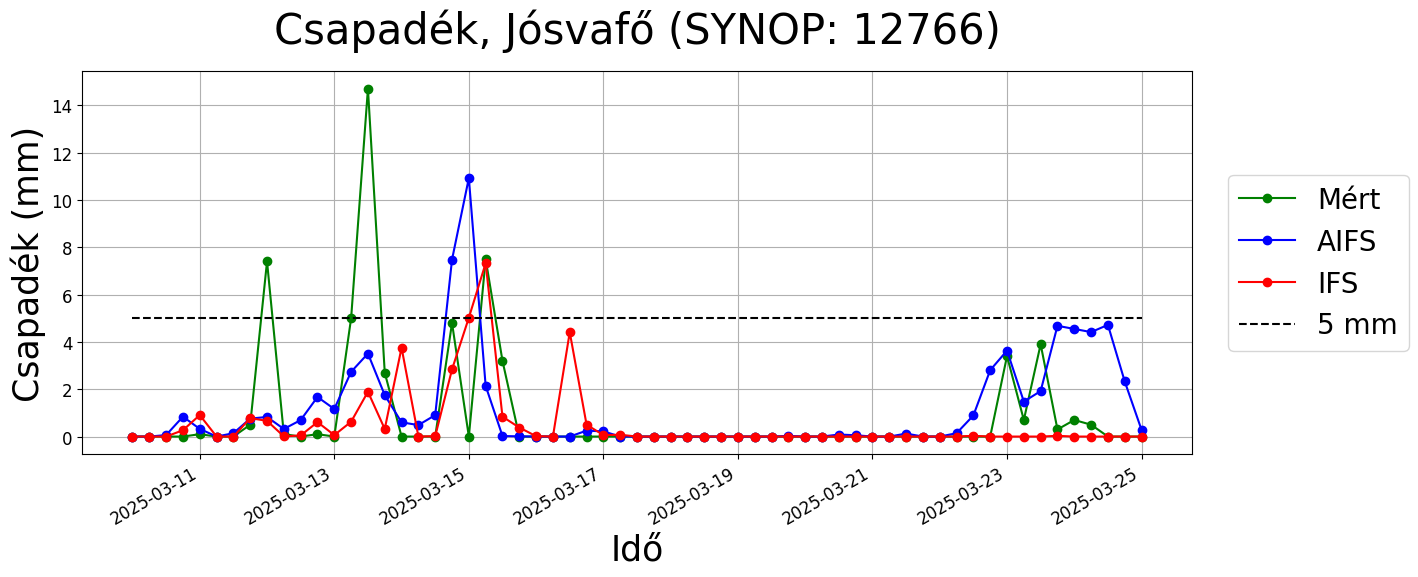

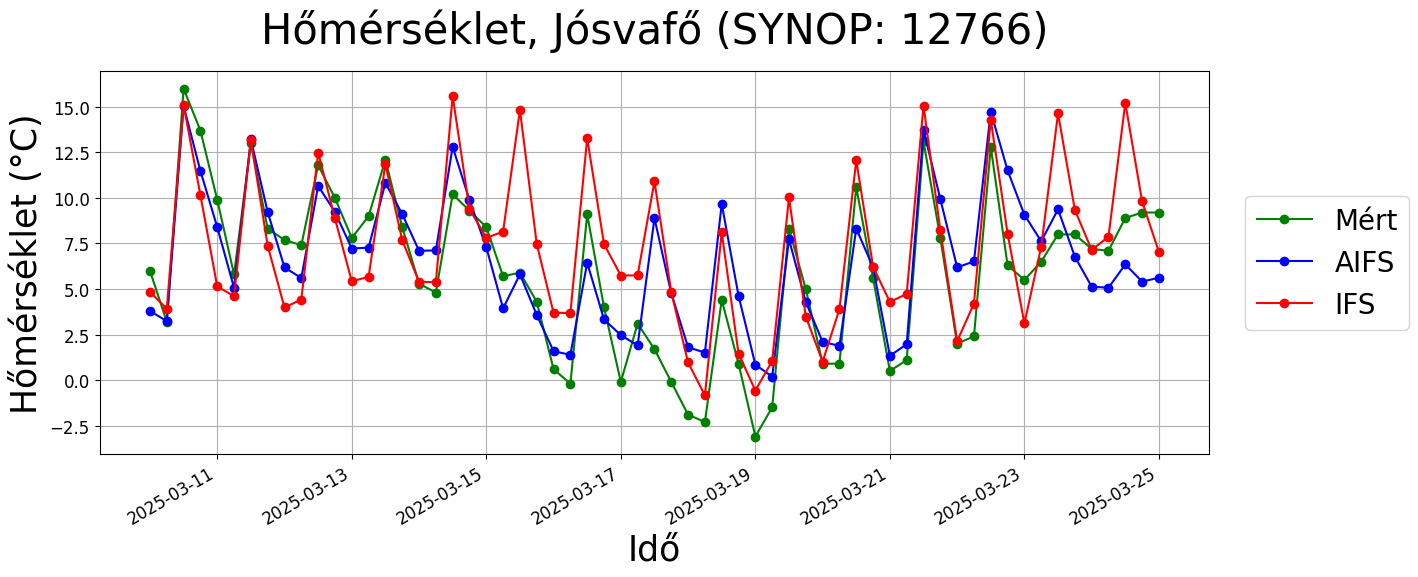

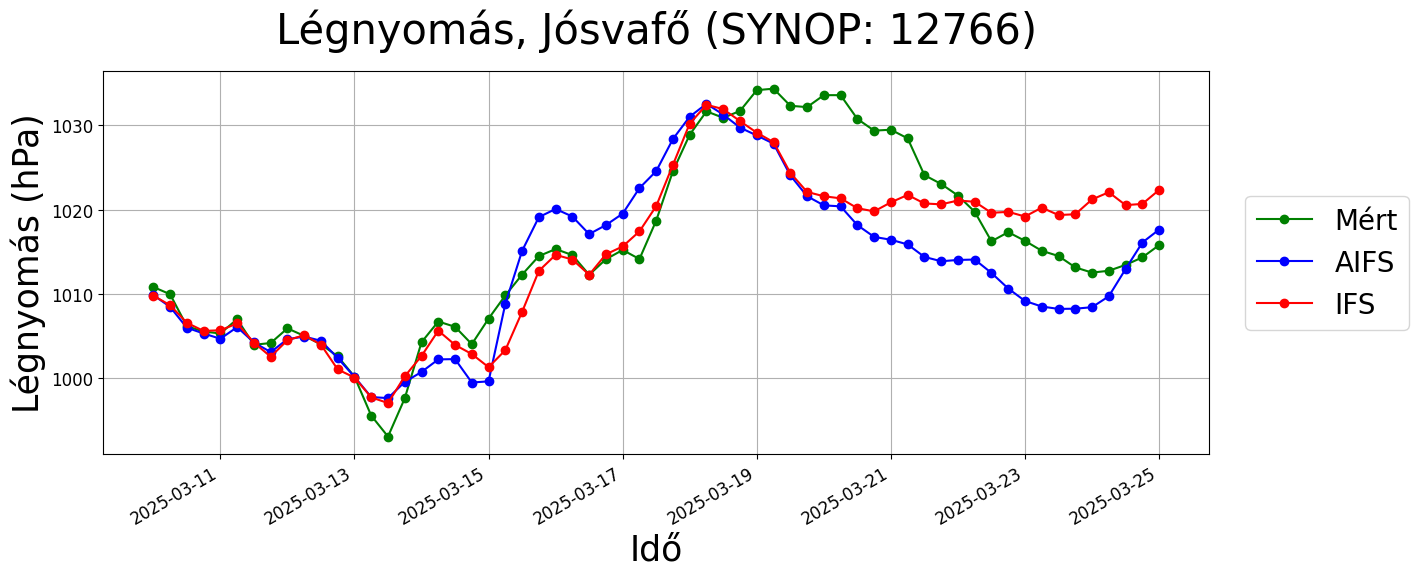

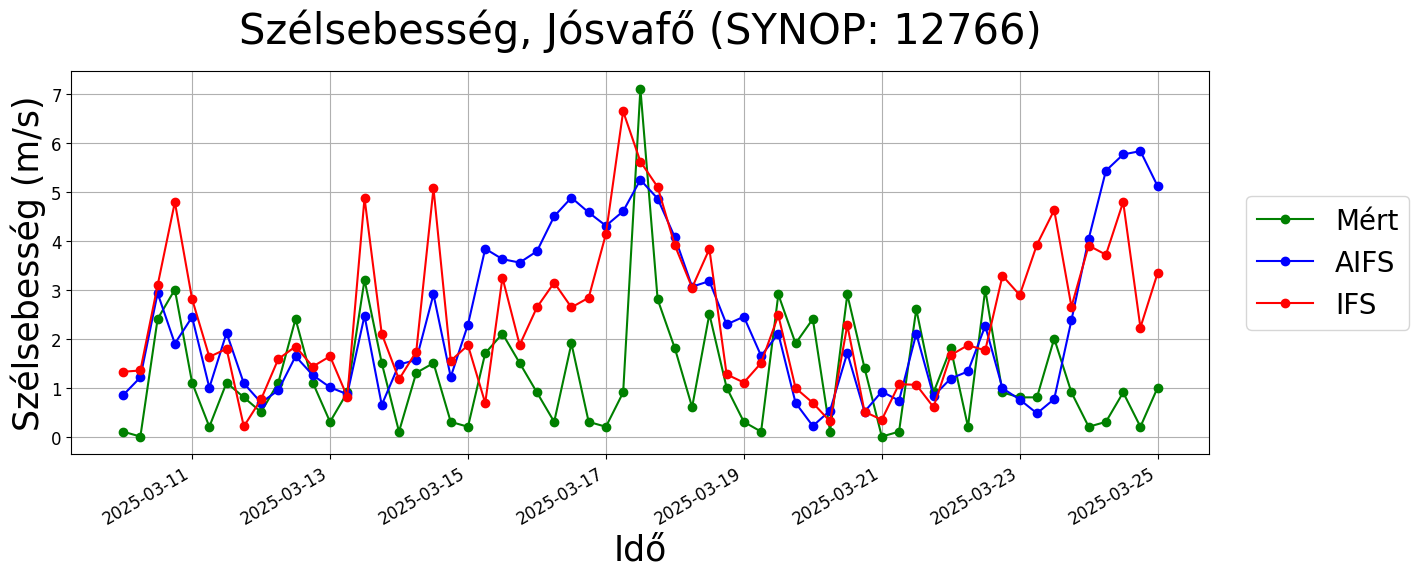

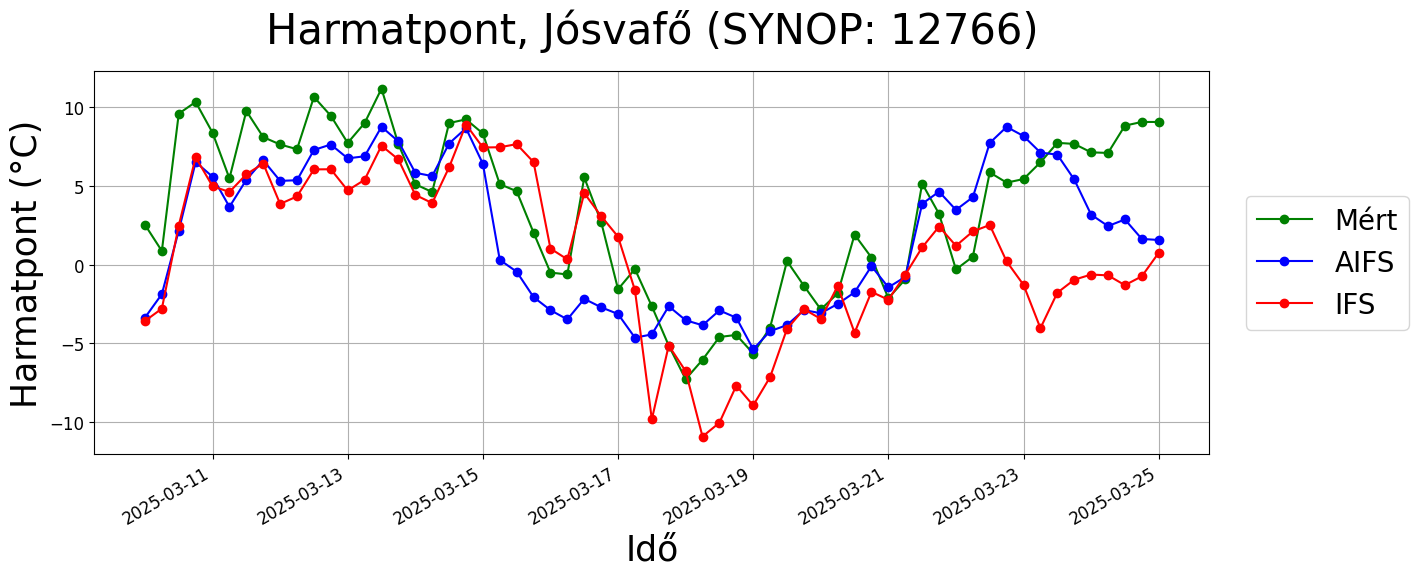


--- Feldolgozás indítása: Debrecen (SYNOP: 12882) (Lat: 47.48417, Lon: 21.60556) ---
A fájl már létezik: stations_meta_auto.csv
A legközelebbi mérőállomás ehhez a helyhez: Debrecen repülőtér                       (Kód: 64711)
Fájl sikeresen letöltve és kicsomagolva
Kicsomagolt fájl: HABP_1H_20250101_20251119_64711.csv
Az állomás tengerszint feletti magassága:     106.6 m
Kinyerem az AIFS adatokat a(z) Debrecen (SYNOP: 12882) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-0h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-6h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-12h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-18h-oper-fc.grib2
Processing: C:\Users\opago\Documents\P

Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Kinyerem az IFS adatokat a(z) Debrecen (SYNOP: 12882) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-0h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-6h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-6h-oper-fc.grib2


...

Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-12h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-12h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-18h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-24h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-30h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-36h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-42h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-48h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-54h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-60h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-66h-oper-fc.grib2
Processing: C:\Users\opa

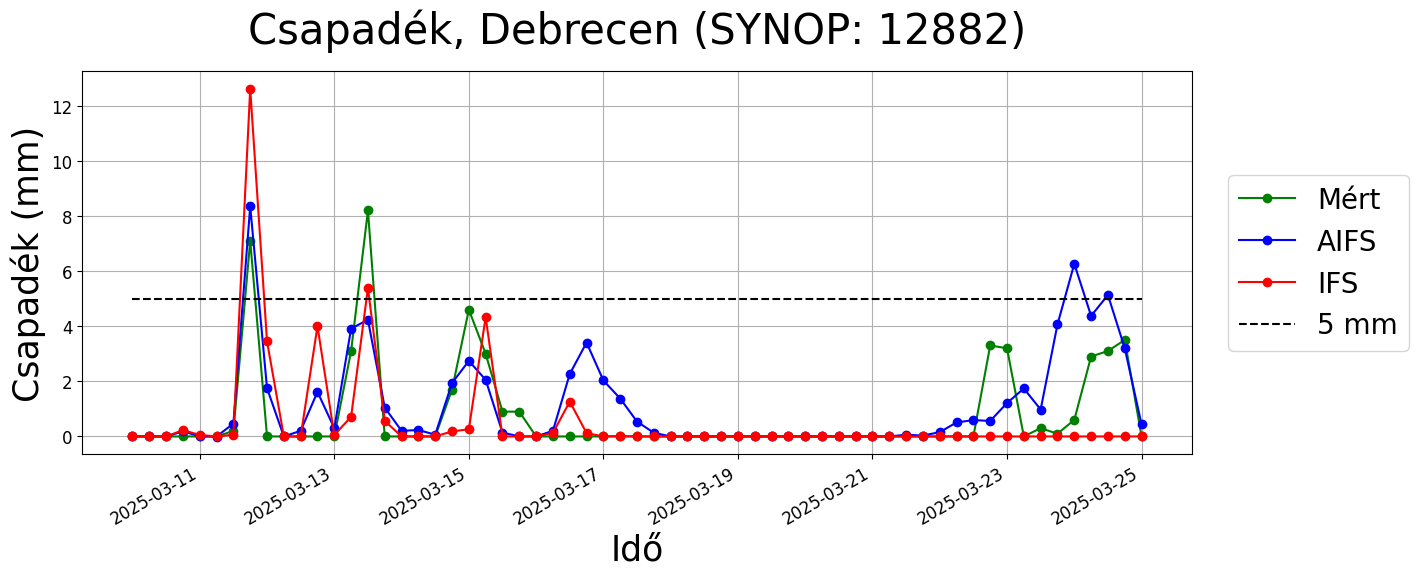

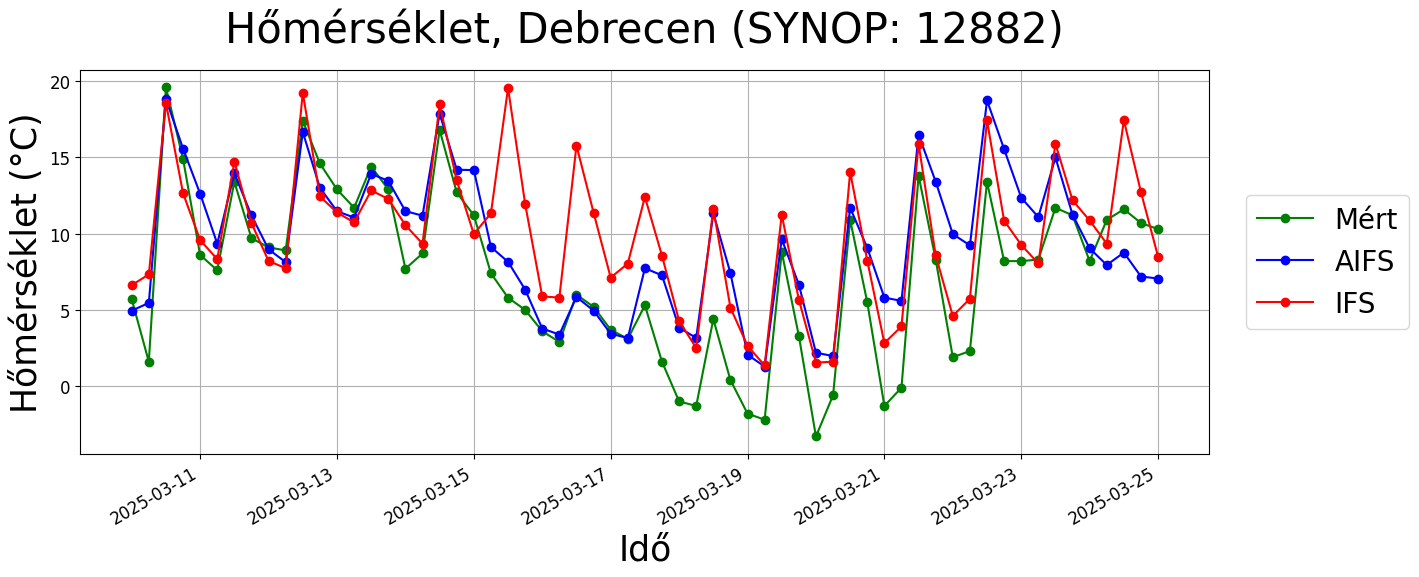

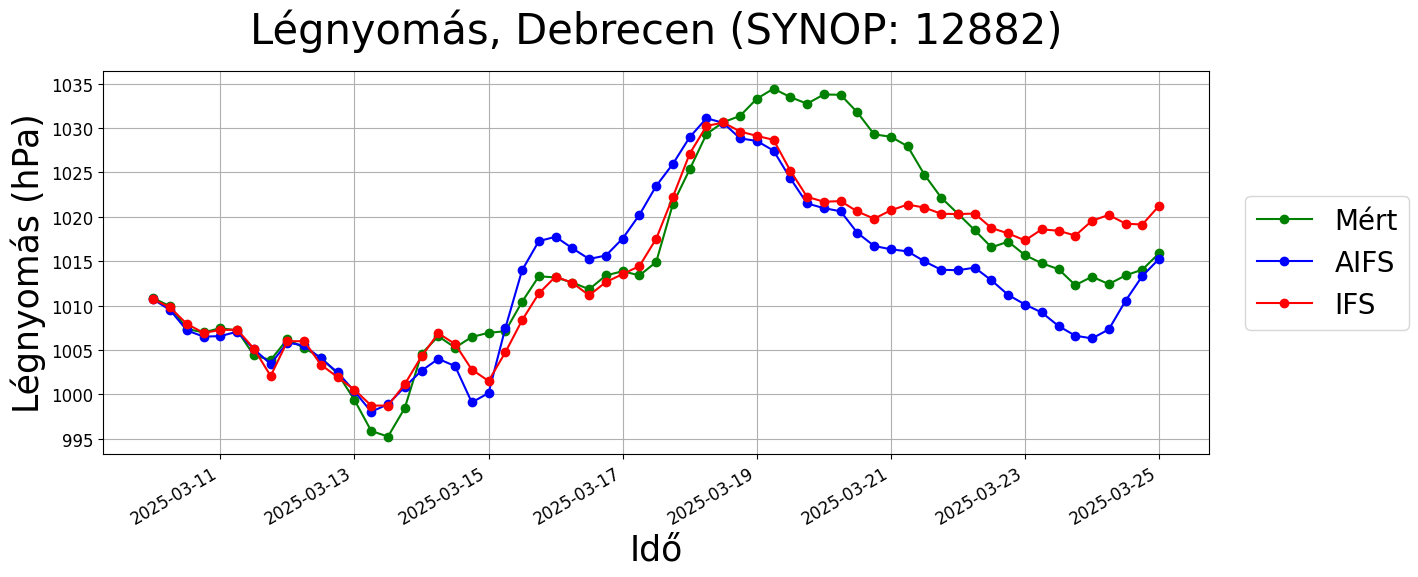

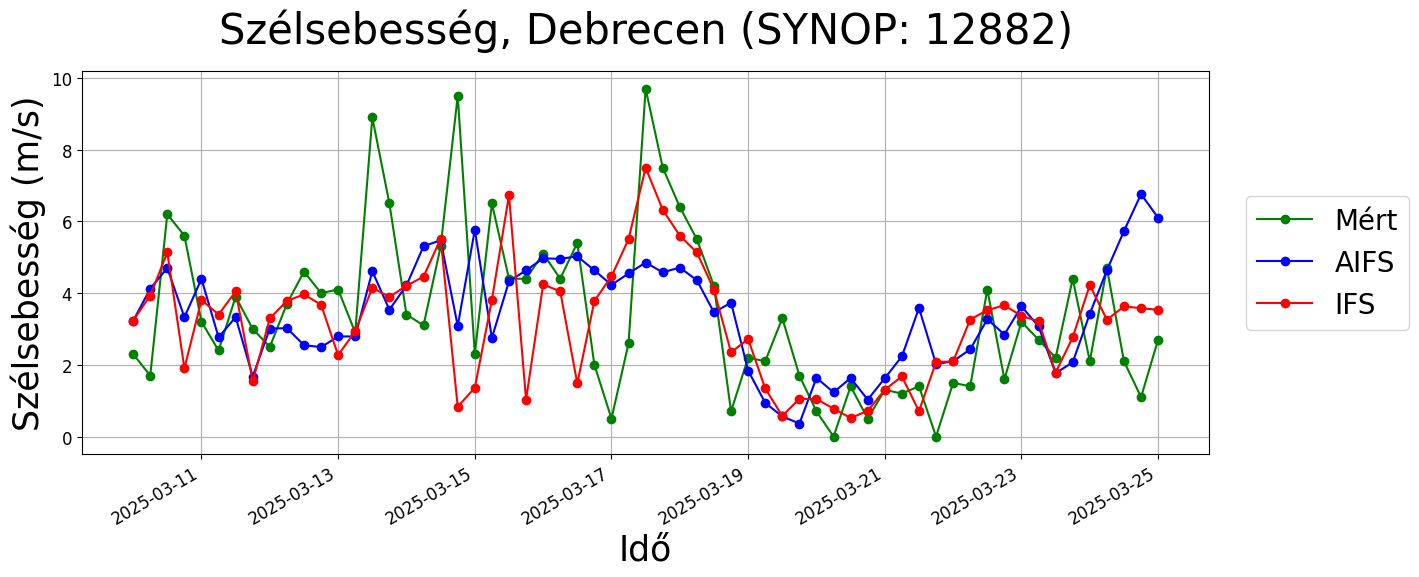

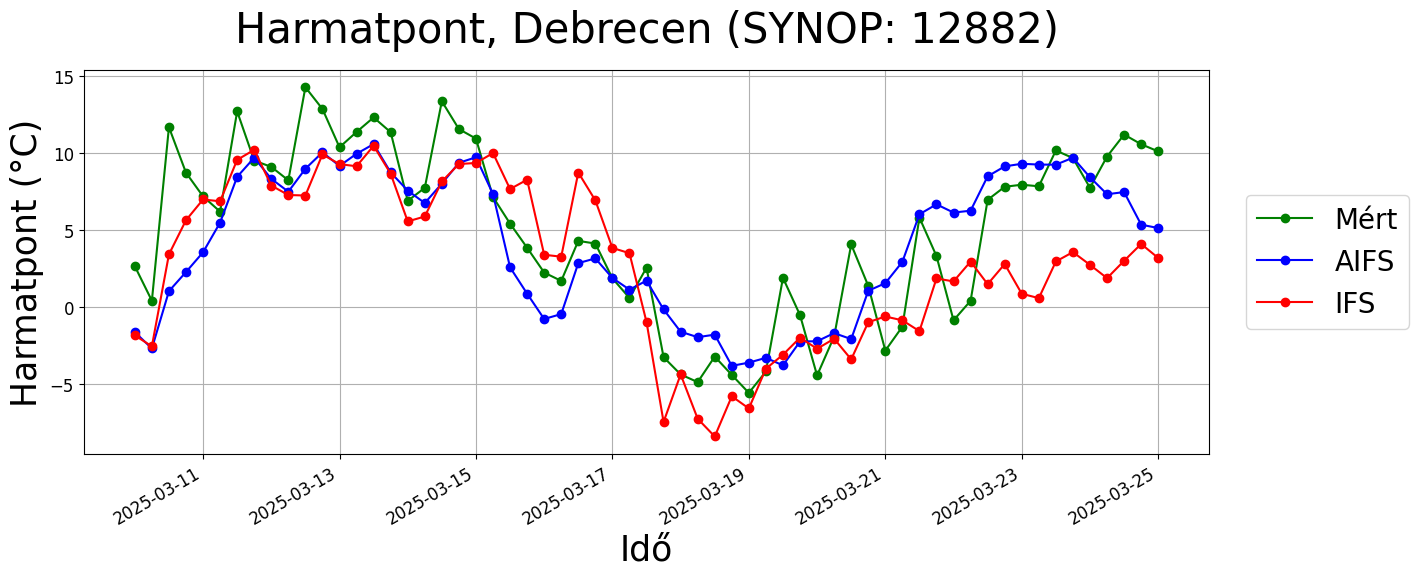


--- Feldolgozás indítása: Siófok (SYNOP: 12935) (Lat: 46.91056, Lon: 18.04056) ---
A fájl már létezik: stations_meta_auto.csv
A legközelebbi mérőállomás ehhez a helyhez: Siófok                                   (Kód: 36100)
Fájl sikeresen letöltve és kicsomagolva
Kicsomagolt fájl: HABP_1H_20250101_20251119_36100.csv
Az állomás tengerszint feletti magassága:     107.2 m
Kinyerem az AIFS adatokat a(z) Siófok (SYNOP: 12935) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-0h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-6h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-12h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25\20250310000000-18h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Proje

Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Kinyerem az IFS adatokat a(z) Siófok (SYNOP: 12935) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-0h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-6h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-6h-oper-fc.grib2


...

Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-12h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-12h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-18h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-24h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-30h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-36h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-42h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-48h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-54h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-60h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-66h-oper-fc.grib2
Processing: C:\Users\opa

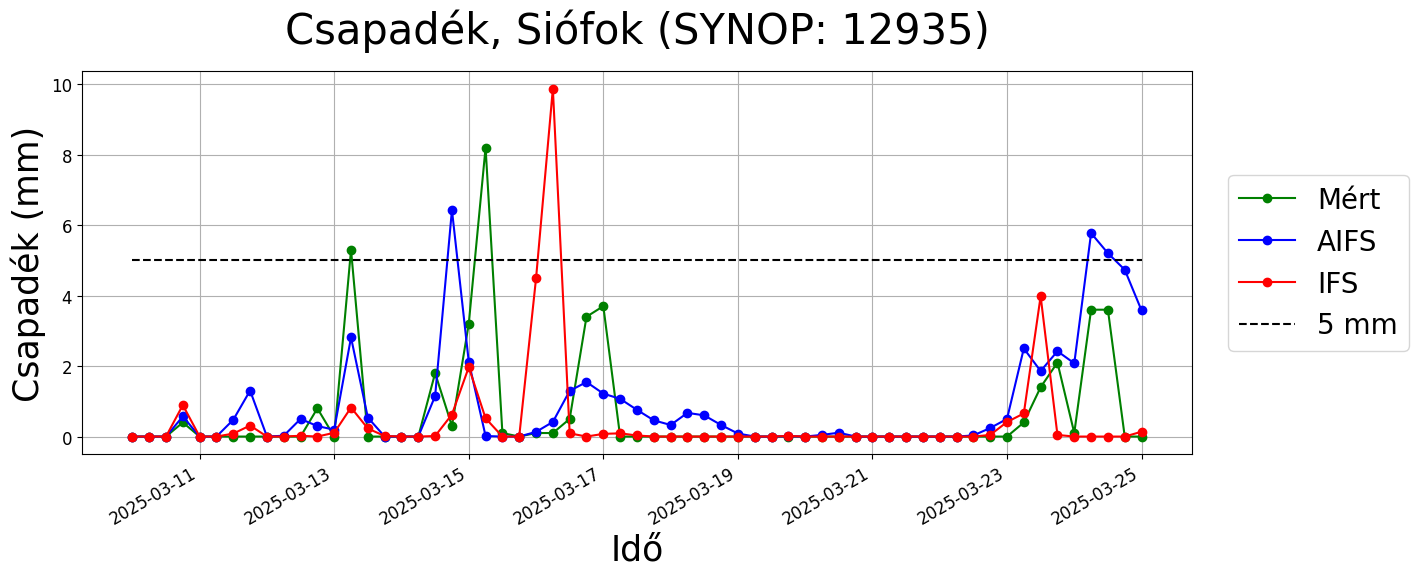

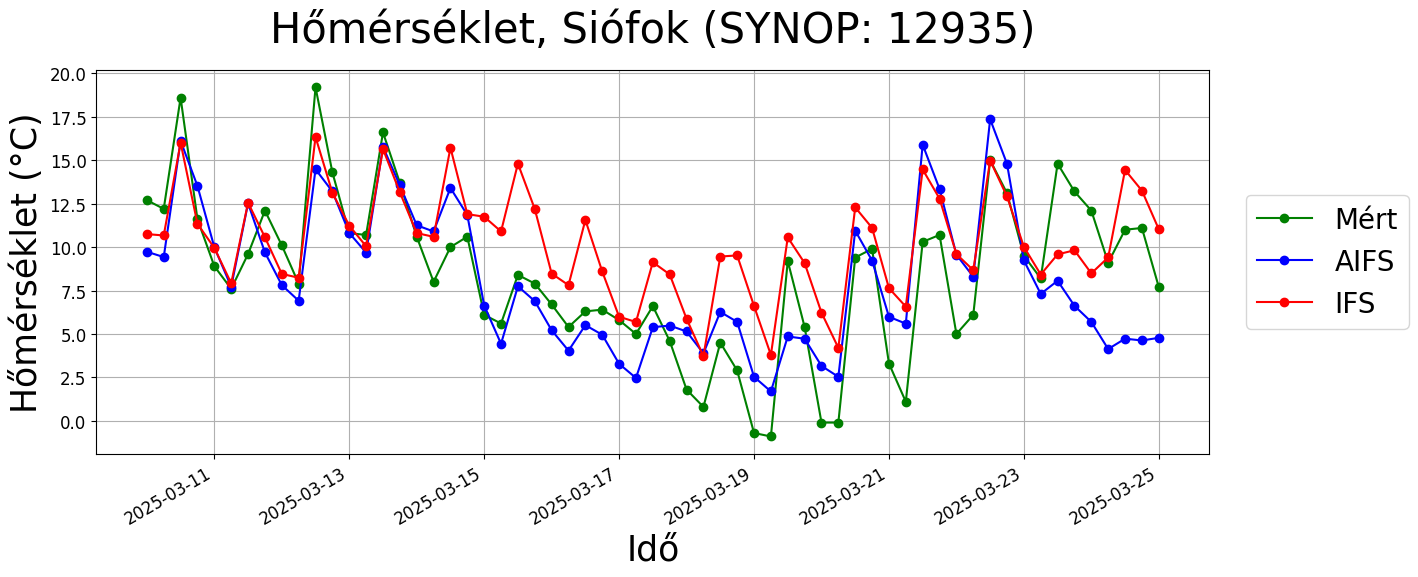

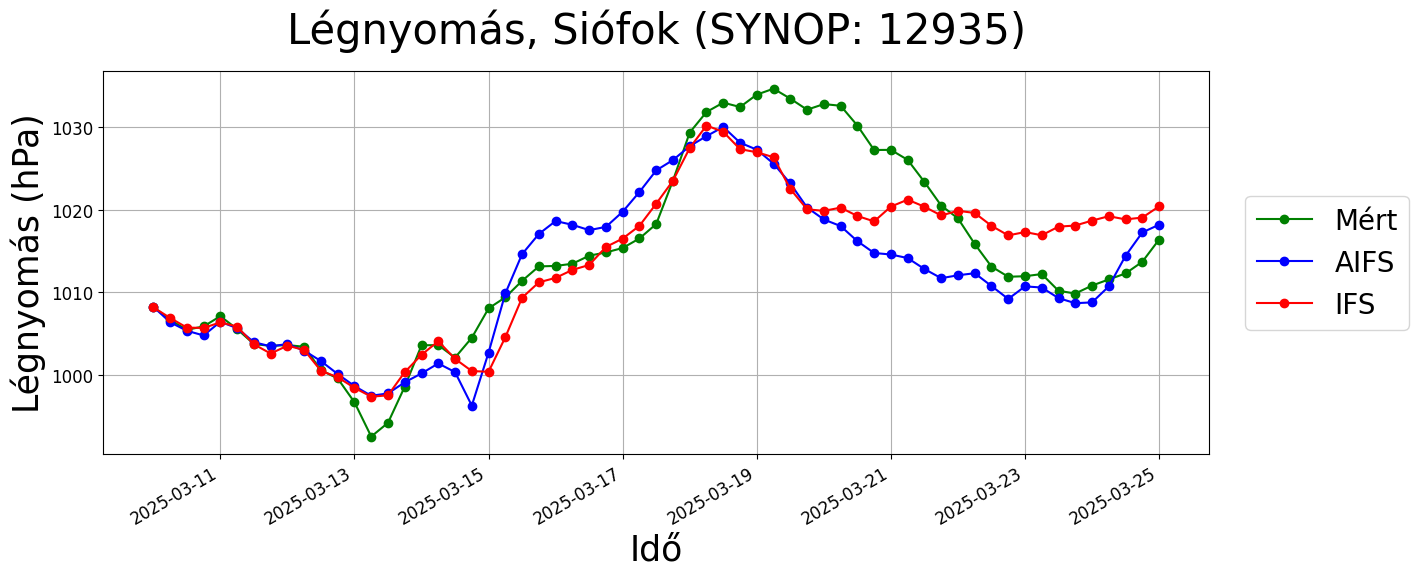

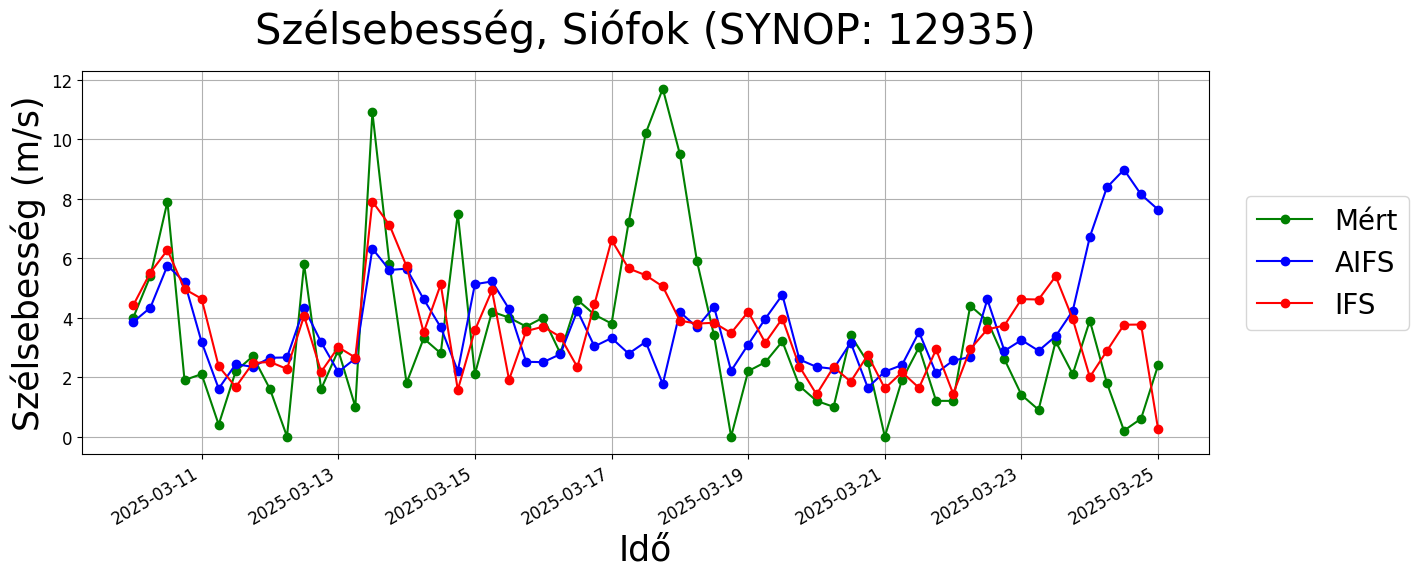

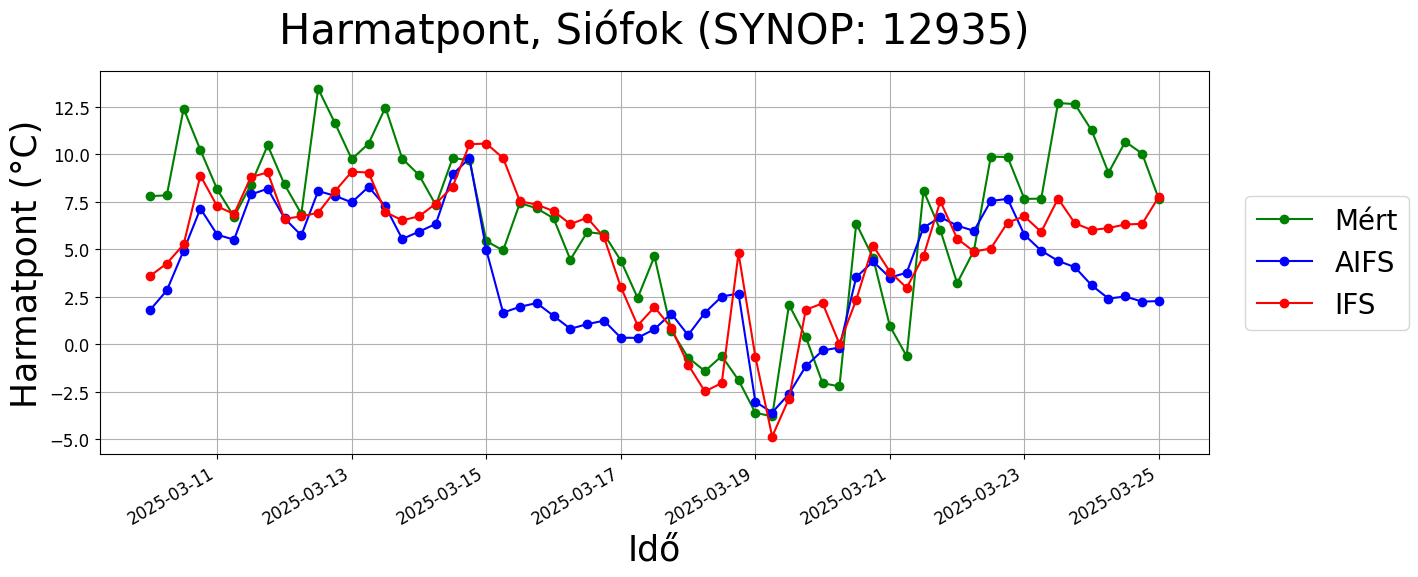


--- Minden állomás feldolgozása befejeződött! ---


In [81]:
def plotAll(city_name, nearest_station_name, aifs_data, ifs_data, measured_data, inittime):
    output_dir = r"C:/Users/opago/Documents/Projektek/TDK/Z_animations_diagrams"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    times_6hourly = aifs_data.times

    def save_plot(y_measured, y_aifs, y_ifs, ylabel, title, filename_suffix, extra_line=None, extra_label=None):
        fig, ax = plt.subplots(figsize=(17, 6))  # Növeltem a magasságot a legenda helyének biztosításához
        ax.plot(times_6hourly, y_measured, label="Mért", color='green', marker='o')
        ax.plot(times_6hourly, y_aifs, label="AIFS", color='blue', marker='o')
        ax.plot(times_6hourly, y_ifs, label="IFS", color='red', marker='o')
        if extra_line is not None:
            ax.plot(times_6hourly, extra_line, label=extra_label, color='black', linestyle='--')
        
        # Középre igazított cím
        ax.set_title(
            f"{title}, {city_name}",
            fontsize=30,
            pad=20  # Távolság a cím és a grafika között
        )
        
        ax.set_ylabel(ylabel, fontsize=25)
        ax.set_xlabel("Idő", fontsize=25)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True)
        
        # Legenda az ábra területén kívül, jobb oldalon
        ax.legend(
            fontsize=20,  # Kicsit kisebb betűméret a jobb illeszkedés érdekében
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),  # Az ábra jobb szélétől kissé kijjebb
            frameon=True,
            fancybox=True
            #shadow=True
        )

        fig.autofmt_xdate()
        
        # Biztosítjuk, hogy a legenda ne vágódjon ki
        plt.tight_layout(rect=[0, 0, 0.85, 1])  # Jobb oldali hely biztosítása a legendának
        
        # Fájl mentése
        filename = f"{city_name}_{filename_suffix}_{inittime.strftime('%Y%m%d%H%M')}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.show()

    save_plot(
        measured_data.precipitation, aifs_data.precipitations, ifs_data.precipitations,
        ylabel="Csapadék (mm)",
        title="Csapadék",
        filename_suffix="csapadek",
        extra_line=[5] * len(times_6hourly),
        extra_label="5 mm"
    )

    save_plot(
        measured_data.temperature, aifs_data.temperatures, ifs_data.temperatures,
        ylabel="Hőmérséklet (°C)",
        title="Hőmérséklet",
        filename_suffix="homerseklet"
    )

    save_plot(
        measured_data.mslp, aifs_data.mslps, ifs_data.mslps,
        ylabel="Légnyomás (hPa)",
        title="Légnyomás",
        filename_suffix="legnyomas"
    )

    save_plot(
        measured_data.wind_speed, aifs_data.winds10, ifs_data.winds10,
        ylabel="Szélsebesség (m/s)",
        title="Szélsebesség",
        filename_suffix="szelsebesseg"
    )

    save_plot(
        measured_data.dewpoint, aifs_data.dewpoints, ifs_data.dewpoints,
        ylabel="Harmatpont (°C)",
        title="Harmatpont",
        filename_suffix="harmatpont"
    )

for city_name, coords in synop_stations.items():
    target_lat, target_lon = coords
    print(f"\n--- Feldolgozás indítása: {city_name} (Lat: {target_lat}, Lon: {target_lon}) ---")

    measured_data = MeasuredData(target_lat, target_lon)

    measured_data.download_metadata() 
    measured_data.load_metadata()

    nearest_station_code, nearest_station_name = measured_data.find_nearest_station()
    print(f"A legközelebbi mérőállomás ehhez a helyhez: {nearest_station_name} (Kód: {nearest_station_code})")
    measured_data.process_csv(nearest_station_code) # Ez letölti és feldolgozza a mért adatokat

    print(f"Kinyerem az AIFS adatokat a(z) {city_name} állomáshoz...")
    aifs.extract_and_store_data_for_station(target_lat, target_lon)
    print(f"Kinyerem az IFS adatokat a(z) {city_name} állomáshoz...")
    ifs.extract_and_store_data_for_station(target_lat, target_lon)

    plotAll(city_name, nearest_station_name, aifs, ifs, measured_data, inittime)

print("\n--- Minden állomás feldolgozása befejeződött! ---")

**IDÁIG TILOS HOZZÁPISZKÁLNI**

In [18]:
inittime = datetime(2025, 3, 10, 0)
forecast_hours = list(range(0, 97, 6)) # 0-4 nap, rövid
#forecast_hours = list(range(96, 241, 6)) # 4-10 nap, közép
#forecast_hours = list(range(240, 361, 6)) # 10-15 nap, hosszú

In [19]:
class ECMWF:  # parent class
    def __init__(self, name, inittime, forecast_hours, base_url):
        self.name = name
        self.inittime = inittime
        self.forecast_hours = forecast_hours
        self.base_url = base_url

        self.times = []
        self.mslps = []
        self.winds10 = []
        self.precipitations = []
        self.temperatures = []
        self.dewpoints = []

        self.dlon, self.dlat, self.lon0, self.lat0 = 0.25, -0.25, -180, 90 #grid paraméterei
        
        # Az adatok útvonala - használjuk a globális konstans útvonalat
        self.data_base_path = GRIB_DATA_BASE_PATH

    def download_grib(self, filename, hour):
        file_url = f"{self.base_url}{self.inittime.strftime('%Y%m%d%H%M%S')}-{hour}h-oper-fc.grib2"
        save_dir = os.path.join(self.data_base_path, f"{self.name}-0p25")
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
        response = requests.get(file_url)
        if response.status_code == 200:
            with open(filename, "wb") as f:
                f.write(response.content)
            print(f"Downloaded: {filename}")
        else:
            print(f"Failed to download: {filename}, Status Code: {response.status_code}")

    def download_all_grib_files(self):
        """Ellenőrzi a GRIB fájlokat, csak letölt ha hiányoznak."""
        save_dir = os.path.join(self.data_base_path, f"{self.name}-0p25")
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        print(f"Checking GRIB files for {self.name} in {save_dir}...")
        
        # Ellenőrizzük, hogy a mappa létezik-e és van-e benne fájl
        if not os.path.exists(save_dir):
            print(f"Directory does not exist: {save_dir}")
            return
            
        files_in_dir = os.listdir(save_dir)
        grib_files = [f for f in files_in_dir if f.endswith('.grib2')]
        
        if grib_files:
            print(f"Found {len(grib_files)} existing GRIB files for {self.name}. Skipping download.")
            return

        print(f"No existing GRIB files found. Downloading for {self.name}...")
        for hour in self.forecast_hours:
            filename = f"{self.inittime.strftime('%Y%m%d%H%M%S')}-{hour}h-oper-fc.grib2"
            file_path = os.path.join(save_dir, filename)

            if not os.path.exists(file_path):
                self.download_grib(file_path, hour)
            else:
                print(f"File already exists: {filename}")

    def extractData(self, filename, j, i):  # metódus az adatok feldolgozására
        try:
            ds = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'instant', 'typeOfLevel': 'meanSea'}, decode_timedelta=True)
            mslp = ds["msl"].values[j, i] / 100
        except Exception:
            mslp = None

        try:
            ds_wind10 = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'instant', 'typeOfLevel': 'heightAboveGround', 'level': 10}, decode_timedelta=True)
            u10, v10 = ds_wind10["u10"].values[j, i], ds_wind10["v10"].values[j, i]
            wind10 = np.sqrt(u10**2 + v10**2)
        except Exception:
            wind10 = None

        try:
            ds_precip = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'accum', 'typeOfLevel': 'surface'}, decode_timedelta=True)
            if self.name == 'aifs-single':
                precipitation = ds_precip["tp"].values[j, i]
            elif self.name == 'ifs':
                precipitation = ds_precip["tp"].values[j, i] * 1000
        except Exception:
            precipitation = None

        try:
            ds_temp = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'instant', 'typeOfLevel': 'heightAboveGround', 'level': 2}, decode_timedelta=True)
            temp = ds_temp["t2m"].values[j, i] - 273.15
        except Exception:
            temp = None

        try:
            ds_dewpoint = xr.open_dataset(filename, engine="cfgrib", filter_by_keys={'stepType': 'instant', 'typeOfLevel': 'heightAboveGround', 'level': 2}, decode_timedelta=True)
            dewpoint = ds_dewpoint["d2m"].values[j, i] - 273.15
        except Exception:
            dewpoint = None

        return mslp, wind10, precipitation, temp, dewpoint

    def extract_and_store_data_for_station(self, target_lat, target_lon):  # metódus az adatok feldolgozásához
        self.times = []
        self.mslps = []
        self.winds10 = []
        self.precipitations = []
        self.temperatures = []
        self.dewpoints = []

        i, j = int(np.round((target_lon - self.lon0) / self.dlon)), int(np.round((target_lat - self.lat0) / self.dlat))
        save_dir = os.path.join(self.data_base_path, f"{self.name}-0p25")

        last_precip_accum = None

        for hour in self.forecast_hours:  # az összes előrejelzési órát feldolgozzuk
            valid_time = self.inittime + timedelta(hours=hour)
            filename = f"{self.inittime.strftime('%Y%m%d%H%M%S')}-{hour}h-oper-fc.grib2"
            file_path = os.path.join(save_dir, filename)

            if not os.path.exists(file_path):
                print(f"Error: GRIB file not found for extraction: {file_path}")
                mslp, wind10, precipitation, temp, dewpoint = None, None, None, None, None
            else:
                print(f"Processing: {file_path}")
                mslp, wind10, precipitation, temp, dewpoint = self.extractData(file_path, j, i)

            self.mslps.append(mslp)
            self.winds10.append(wind10)
            self.temperatures.append(temp)
            self.dewpoints.append(dewpoint)
            self.times.append(valid_time)

            if last_precip_accum is None:
                six_hourly_precip = 0.0
            else:
                six_hourly_precip = precipitation - last_precip_accum if precipitation is not None and last_precip_accum is not None else None

            self.precipitations.append(six_hourly_precip)
            last_precip_accum = precipitation

In [20]:
class MeasuredData:
    def __init__(self, target_lat, target_lon):
        self.target_lat = target_lat
        self.target_lon = target_lon
        self.metadata = []
        self.station_code = None
        self.timestamps = []
        self.precipitation = []
        self.temperature = []
        self.pressure = []
        self.humidity = []
        self.wind_speed = []
        self.dewpoint = []
        self.elevation = []
        self.mslp = []

    def download_metadata(self):
        metadata_url = 'https://odp.met.hu/climate/observations_hungary/hourly/station_meta_auto.csv'
        output_filename = "stations_meta_auto.csv"

        if os.path.exists(output_filename):
            print(f"A fájl már létezik: {output_filename}")
            return output_filename

        response = requests.get(metadata_url)
        if response.status_code == 200:
            with open(output_filename, "wb") as file:
                file.write(response.content)
            print(f"Fájl sikeresen letöltve: {output_filename}")
            return output_filename
        else:
            print(f"Hiba történt a letöltés során: {response.status_code}")
            return None

    def load_metadata(self):
        filename = "stations_meta_auto.csv"
        with open(filename, mode="r", encoding="utf-8") as file:
            csv_metadata = csv.reader(file, delimiter=";")
            next(csv_metadata)  #fejléc átugrása
            
            for row in csv_metadata:
                lat = float(row[3])  #latitude a 4. oszlopban van
                lon = float(row[4])  #longitude az 5.-ben
                station_code = row[0]  #station number az 1.-ben
                station_name = row[6]  #állomásnév a 7.-ben
                self.metadata.append((lat, lon, station_code, station_name)) #eltárolja a metadata-t

    def find_nearest_station(self): #metódus a legközelebbi állomás megkeresésére a target koordináták alapján
        #legkisebb négyzetes eltérés
        distances = [(np.square(lat - self.target_lat) + np.square(lon - self.target_lon), station_code, station_name)
                     for lat, lon, station_code, station_name in self.metadata]
                
        nearest_station = min(distances, key=lambda x: x[0])  #key=lambda x: x[0] rész: a distances-ben lévő tuple-ök első elemét adja vissza (ami a távolság)
        #tehát a nearest_station is egy tuple: nulladik eleme a távolság, első a station code, második pedig a station name
        nearest_station_code = nearest_station[1]
        nearest_station_code = nearest_station_code.strip()  #Szóközök eltávolítása
        nearest_station_name = nearest_station[2]
        
        return nearest_station_code, nearest_station_name

    def download_and_extract_zip(self, station_code): #metódus a zip feldolgozására

        zip_url = f"https://odp.met.hu/climate/observations_hungary/hourly/recent/HABP_1H_{station_code}_akt.zip"
        response = requests.get(zip_url) #letölti a zip-et
        
        if response.status_code == 200: #ha OK, kicsomagolja
            with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
                csv_file = zip_ref.namelist()[0]  #a fájl neve
                zip_ref.extract(csv_file, "station_data") #kicsomagolás
                print(f"Fájl sikeresen letöltve és kicsomagolva")
                print(f"Kicsomagolt fájl: {csv_file}")
                return os.path.join("station_data", csv_file) #visszatérési érték: a csv fájl elérési útja
        else:
            print(f"Hiba történt a ZIP fájl letöltésekor: {response.status_code}")
            return None

    # TETENS-FORMULA INVERZE ALAPJÁN        
    def calculate_dewpoint(self, T, RH):
        if T is None or RH is None or RH == 0:
            return None
        if RH <= 0: #nem pozitív szám log-a
            return None
        gamma = (17.3 * T) / (T + 237.3) + math.log10(RH / 100)
        if (17.3 - gamma) == 0: #0-val osztás
            return None
        Td = (237.3 * gamma) / (17.3 - gamma)
        return Td

    def process_csv(self, station_code):
        file_path = self.download_and_extract_zip(station_code)  # ZIP fájl letöltése és kibontása
        if not file_path:
            print('Nem sikerült letölteni vagy kibontani a CSV fájlt!')
            return

        self.timestamps = []
        self.precipitation = []
        self.temperature = []
        self.pressure = []
        self.humidity = []
        self.wind_speed = []
        self.dewpoint = []
        self.mslp = []

        start_date = inittime  # Kezdő dátum (datetime objektum)
        # 0, 6, 12, ..., 360 óra
        forecast_hours_measure = list(forecast_hours)
        valid_times = {start_date + timedelta(hours=h) for h in forecast_hours_measure}

        with open(file_path, mode="r", encoding="utf-8") as file:
            csv_file = csv.reader(file, delimiter=";")
            # Fejléc és az első adatblokk átlépése
            for _ in range(2):
                next(csv_file)
            row = next(csv_file)
            elevation = row[5]
            self.elevation = elevation
            print('Az állomás tengerszint feletti magassága:', elevation, 'm')
            for _ in range(6):
                next(csv_file)

            # Store all hourly precipitation values first
            hourly_data = []
            for row in csv_file:
                try:
                    timestamp_str = row[1]
                    # Ensure timestamp_str has enough characters for parsing
                    if len(timestamp_str) >= 12:
                        timestamp = datetime.strptime(timestamp_str, "%Y%m%d%H%M")
                    else:
                        print(f"Skipping row due to invalid timestamp format: {row}")
                        continue

                    if not (start_date <= timestamp <= start_date + timedelta(hours=360)):
                        continue

                    hourly_data.append({
                        "timestamp": timestamp,
                        "precipitation": float(row[2]) if row[2] else 0.0,
                        "temp": float(row[4]) if row[4] else None,
                        "press": float(row[14]) if row[14] else None,
                        "hum": float(row[16]) if row[16] else None,
                        "ws": float(row[24]) if row[24] else None
                    })
                except ValueError as ve:
                    print(f"Data conversion error in row: {row}. Error: {ve}")
                except IndexError as ie:
                    print(f"Index error in row (missing column?): {row}. Error: {ie}")
                except Exception as e:
                    print(f"Unexpected error processing row: {row}. Error: {e}")


            # Process hourly data to get 6-hourly accumulated precipitation and other values at 6-hour intervals
            current_precip_6h_acc = 0.0
            last_timestamp = None
            
            for i, data in enumerate(hourly_data):
                timestamp = data["timestamp"]
                precipitation = data["precipitation"]

                if last_timestamp is None:
                    last_timestamp = timestamp
                
                # Check if it's time for a 6-hourly accumulation point
                # This logic ensures we accumulate correctly over 6 hours and store at the 6-hour marks
                if (timestamp.hour % 6 == 0 and (timestamp - start_date).total_seconds() / 3600 % 6 == 0) or \
                   (i == len(hourly_data) - 1 and (timestamp - start_date).total_seconds() / 3600 % 6 != 0): # For the last point if it's not exactly on a 6-hour mark
                    
                    if timestamp in valid_times:
                        self.timestamps.append(timestamp)
                        self.precipitation.append(current_precip_6h_acc + precipitation) # Add current hour's precip to accumulation
                        self.temperature.append(data["temp"])
                        self.pressure.append(data["press"])
                        self.humidity.append(data["hum"])
                        self.dewpoint.append(self.calculate_dewpoint(data["temp"], data["hum"]))
                        self.wind_speed.append(data["ws"])
                        current_precip_6h_acc = 0.0 # Reset for next 6-hour block
                    else:
                        current_precip_6h_acc += precipitation # Continue accumulating if not a valid_time for storing
                else:
                    current_precip_6h_acc += precipitation

                last_timestamp = timestamp
        
        # MSLP átszámítása
        M = 0.0289644
        L = 0.0065
        T0 = 288.15
        g = 9.80665
        R = 8.31432
        h = float(self.elevation) if self.elevation else None

        if h is None:
            self.mslp = [np.nan] * len(self.pressure)
        else:
            self.mslp = []  # inicializáljuk a listát
            for p, t in zip(self.pressure, self.temperature):
                if p is None or np.isnan(p) or p <= 0:
                    mslp = np.nan
                elif t is None or np.isnan(t):
                    mslp = np.nan
                else:
                    t_kelvin = t + 273.15 
                    factor = 1 - (L * h / t_kelvin) 
                    
                    if factor <= 0:
                        mslp = np.nan
                    else:
                        exponent = g * M / (R * L)
                        exponent_original = -1 * exponent
                        mslp = p * (factor ** exponent_original)
                self.mslp.append(mslp)

In [21]:
class AIFS(ECMWF):
    def __init__(self, inittime):
        super().__init__("aifs-single", inittime, forecast_hours, 
                         f"https://data.ecmwf.int/forecasts/{inittime.strftime('%Y%m%d')}/{inittime.strftime('%Hz')}/aifs-single/0p25/oper/")

class IFS(ECMWF):
    def __init__(self, inittime):
        super().__init__("ifs", inittime, forecast_hours, 
                         f"https://data.ecmwf.int/forecasts/{inittime.strftime('%Y%m%d')}/{inittime.strftime('%Hz')}/ifs/0p25/oper/")


In [22]:
aifs = AIFS(inittime)
ifs = IFS(inittime)
print("\n--- ECMWF GRIB fájlok előzetes letöltése és ellenőrzése ---")
aifs.download_all_grib_files()
ifs.download_all_grib_files()
print("--- ECMWF GRIB fájlok letöltése/ellenőrzése befejezve ---")

MERT_TEMP_DB = []
MERT_TEMP_JF = []
MERT_TEMP_SF = []

MERT_DEWP_DB = []
MERT_DEWP_JF = []
MERT_DEWP_SF = []

MERT_MSLP_DB = []
MERT_MSLP_JF = []
MERT_MSLP_SF = []

MERT_WIND_DB = []
MERT_WIND_JF = []
MERT_WIND_SF = []

AIFS_TEMP_DB = []
AIFS_TEMP_JF = []
AIFS_TEMP_SF = []

AIFS_DEWP_DB = []
AIFS_DEWP_JF = []
AIFS_DEWP_SF = []

AIFS_MSLP_DB = []
AIFS_MSLP_JF = []
AIFS_MSLP_SF = []

AIFS_WIND_DB = []
AIFS_WIND_JF = []
AIFS_WIND_SF = []

IFS_TEMP_DB = []
IFS_TEMP_JF = []
IFS_TEMP_SF = []

IFS_DEWP_DB = []
IFS_DEWP_JF = []
IFS_DEWP_SF = []

IFS_MSLP_DB = []
IFS_MSLP_JF = []
IFS_MSLP_SF = []

IFS_WIND_DB = []
IFS_WIND_JF = []
IFS_WIND_SF = []

# Városonkénti feldolgozás
stations_list = list(synop_stations.items())
for idx, (city_name, coords) in enumerate(stations_list):
    target_lat, target_lon = coords
    print(f"\n--- Feldolgozás indítása: {city_name} (Lat: {target_lat}, Lon: {target_lon}) ---")

    measured_data = MeasuredData(target_lat, target_lon)

    measured_data.download_metadata() 
    measured_data.load_metadata()

    nearest_station_code, nearest_station_name = measured_data.find_nearest_station()
    print(f"A legközelebbi mérőállomás ehhez a helyhez: {nearest_station_name} (Kód: {nearest_station_code})")
    measured_data.process_csv(nearest_station_code)

    print(f"Kinyerem az AIFS adatokat a(z) {city_name} állomáshoz...")
    aifs.extract_and_store_data_for_station(target_lat, target_lon)
    print(f"Kinyerem az IFS adatokat a(z) {city_name} állomáshoz...")
    ifs.extract_and_store_data_for_station(target_lat, target_lon)
    
    # Adatok hozzárendelése a megfelelő listákhoz
    if "Debrecen" in city_name:
        MERT_TEMP_DB = measured_data.temperature
        MERT_DEWP_DB = measured_data.dewpoint
        MERT_MSLP_DB = measured_data.mslp
        MERT_WIND_DB = measured_data.wind_speed
        
        AIFS_TEMP_DB = aifs.temperatures
        AIFS_DEWP_DB = aifs.dewpoints
        AIFS_MSLP_DB = aifs.mslps
        AIFS_WIND_DB = aifs.winds10
        
        IFS_TEMP_DB = ifs.temperatures
        IFS_DEWP_DB = ifs.dewpoints
        IFS_MSLP_DB = ifs.mslps
        IFS_WIND_DB = ifs.winds10
        
    elif "Jósvafő" in city_name:
        MERT_TEMP_JF = measured_data.temperature
        MERT_DEWP_JF = measured_data.dewpoint
        MERT_MSLP_JF = measured_data.mslp
        MERT_WIND_JF = measured_data.wind_speed
        
        AIFS_TEMP_JF = aifs.temperatures
        AIFS_DEWP_JF = aifs.dewpoints
        AIFS_MSLP_JF = aifs.mslps
        AIFS_WIND_JF = aifs.winds10
        
        IFS_TEMP_JF = ifs.temperatures
        IFS_DEWP_JF = ifs.dewpoints
        IFS_MSLP_JF = ifs.mslps
        IFS_WIND_JF = ifs.winds10
        
    elif "Siófok" in city_name:
        MERT_TEMP_SF = measured_data.temperature
        MERT_DEWP_SF = measured_data.dewpoint
        MERT_MSLP_SF = measured_data.mslp
        MERT_WIND_SF = measured_data.wind_speed
        
        AIFS_TEMP_SF = aifs.temperatures
        AIFS_DEWP_SF = aifs.dewpoints
        AIFS_MSLP_SF = aifs.mslps
        AIFS_WIND_SF = aifs.winds10
        
        IFS_TEMP_SF = ifs.temperatures
        IFS_DEWP_SF = ifs.dewpoints
        IFS_MSLP_SF = ifs.mslps
        IFS_WIND_SF = ifs.winds10

print("\n--- Minden állomás feldolgozása befejeződött! ---")

# Adatok kiíratása ellenőrzésként
print(f"\n--- DEBRECEN adatok ---")
print(f"Mért hőmérséklet: {len(MERT_TEMP_DB)} elem")
print(f"AIFS hőmérséklet: {len(AIFS_TEMP_DB)} elem")
print(f"IFS hőmérséklet: {len(IFS_TEMP_DB)} elem")

print(f"\n--- JÓSVAFŐ adatok ---")
print(f"Mért hőmérséklet: {len(MERT_TEMP_JF)} elem")
print(f"AIFS hőmérséklet: {len(AIFS_TEMP_JF)} elem")
print(f"IFS hőmérséklet: {len(IFS_TEMP_JF)} elem")

print(f"\n--- SIÓFOK adatok ---")
print(f"Mért hőmérséklet: {len(MERT_TEMP_SF)} elem")
print(f"AIFS hőmérséklet: {len(AIFS_TEMP_SF)} elem")
print(f"IFS hőmérséklet: {len(IFS_TEMP_SF)} elem")


--- ECMWF GRIB fájlok előzetes letöltése és ellenőrzése ---
Checking GRIB files for aifs-single in C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\aifs-single-0p25...
Found 61 existing GRIB files for aifs-single. Skipping download.
Checking GRIB files for ifs in C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25...
Found 85 existing GRIB files for ifs. Skipping download.
--- ECMWF GRIB fájlok letöltése/ellenőrzése befejezve ---

--- Feldolgozás indítása: Jósvafő (SYNOP: 12766) (Lat: 48.49528, Lon: 20.53583) ---
A fájl már létezik: stations_meta_auto.csv
A legközelebbi mérőállomás ehhez a helyhez: Jósvafő                                  (Kód: 51705)
Fájl sikeresen letöltve és kicsomagolva
Kicsomagolt fájl: HABP_1H_20250101_20251119_51705.csv
Az állomás tengerszint feletti magassága:     307.9 m
Kinyerem az AIFS adatokat a(z) Jósvafő (SYNOP: 12766) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310

Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Kinyerem az IFS adatokat a(z) Jósvafő (SYNOP: 12766) állomáshoz...
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-0h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-0h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-6h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-6h-oper-fc.grib2


...

Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-12h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-12h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-18h-oper-fc.grib2


Ignoring index file 'C:\\Users\\opago\\Documents\\Projektek\\TDK\\tdk\\ecmwf_grib_data_20250310\\ifs-0p25\\20250310000000-18h-oper-fc.grib2.5b7b6.idx' incompatible with GRIB file


Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-24h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-30h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-36h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-42h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-48h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-54h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-60h-oper-fc.grib2
Processing: C:\Users\opago\Documents\Projektek\TDK\tdk\ecmwf_grib_data_20250310\ifs-0p25\20250310000000-66h-oper-fc.grib2
Processing: C:\Users\opa

In [23]:
def calculate_metrics(measured, forecast):
    valid_pairs = [(m, f) for m, f in zip(measured, forecast) 
                   if m is not None and f is not None 
                   and not np.isnan(m) and not np.isnan(f)]
    
    if not valid_pairs:
        return {
            'NMAE': np.nan,
            'NRMSE': np.nan,
            'PEARSONR': np.nan
        }
    
    m_vals, f_vals = zip(*valid_pairs)
    m_arr = np.array(m_vals)
    f_arr = np.array(f_vals)
    
    # Calculate metrics
    errors = f_arr - m_arr
    abs_errors = np.abs(errors)
    
    nmae = np.mean(abs_errors) / np.std(m_arr)
    rmse = np.sqrt(np.mean(errors**2)) / np.std(m_arr)
    
    # Pearson correlation
    if len(m_arr) > 1:
        c, _ = pearsonr(f_arr, m_arr)
    else:
        c = np.nan
    
    return {
        'NMAE': nmae,
        'RMSE': rmse,
        'PEARSONR': c,
    }

**MÉRÉSEK SZÓRÁSAI**

In [24]:
sigma_meres_TEMP_DB = np.std(MERT_TEMP_DB)
sigma_meres_DEWP_DB = np.std(MERT_DEWP_DB)
sigma_meres_MSLP_DB = np.std(MERT_MSLP_DB)
sigma_meres_WIND_DB = np.std(MERT_WIND_DB)

sigma_meres_TEMP_JF = np.std(MERT_TEMP_JF)
sigma_meres_DEWP_JF = np.std(MERT_DEWP_JF)
sigma_meres_MSLP_JF = np.std(MERT_MSLP_JF)
sigma_meres_WIND_JF = np.std(MERT_WIND_JF)

sigma_meres_TEMP_SF = np.std(MERT_TEMP_SF)
sigma_meres_DEWP_SF = np.std(MERT_DEWP_SF)
sigma_meres_MSLP_SF = np.std(MERT_MSLP_SF)
sigma_meres_WIND_SF = np.std(MERT_WIND_SF)

**PEARSONR-K**

In [25]:
PEARSONR_AIFS_TEMP_DB, _ = pearsonr(AIFS_TEMP_DB, MERT_TEMP_DB)
PEARSONR_AIFS_DEWP_DB, _ = pearsonr(AIFS_DEWP_DB, MERT_DEWP_DB)
PEARSONR_AIFS_MSLP_DB, _ = pearsonr(AIFS_MSLP_DB, MERT_MSLP_DB)
PEARSONR_AIFS_WIND_DB, _ = pearsonr(AIFS_WIND_DB, MERT_WIND_DB)

PEARSONR_AIFS_TEMP_JF, _ = pearsonr(AIFS_TEMP_JF, MERT_TEMP_JF)
PEARSONR_AIFS_DEWP_JF, _ = pearsonr(AIFS_DEWP_JF, MERT_DEWP_JF)
PEARSONR_AIFS_MSLP_JF, _ = pearsonr(AIFS_MSLP_JF, MERT_MSLP_JF)
PEARSONR_AIFS_WIND_JF, _ = pearsonr(AIFS_WIND_JF, MERT_WIND_JF)

PEARSONR_AIFS_TEMP_SF, _ = pearsonr(AIFS_TEMP_SF, MERT_TEMP_SF)
PEARSONR_AIFS_DEWP_SF, _ = pearsonr(AIFS_DEWP_SF, MERT_DEWP_SF)
PEARSONR_AIFS_MSLP_SF, _ = pearsonr(AIFS_MSLP_SF, MERT_MSLP_SF)
PEARSONR_AIFS_WIND_SF, _ = pearsonr(AIFS_WIND_SF, MERT_WIND_SF)

PEARSONR_IFS_TEMP_DB, _ = pearsonr(IFS_TEMP_DB, MERT_TEMP_DB)
PEARSONR_IFS_DEWP_DB, _ = pearsonr(IFS_DEWP_DB, MERT_DEWP_DB)
PEARSONR_IFS_MSLP_DB, _ = pearsonr(IFS_MSLP_DB, MERT_MSLP_DB)
PEARSONR_IFS_WIND_DB, _ = pearsonr(IFS_WIND_DB, MERT_WIND_DB)

PEARSONR_IFS_TEMP_JF, _ = pearsonr(IFS_TEMP_JF, MERT_TEMP_JF)
PEARSONR_IFS_DEWP_JF, _ = pearsonr(IFS_DEWP_JF, MERT_DEWP_JF)
PEARSONR_IFS_MSLP_JF, _ = pearsonr(IFS_MSLP_JF, MERT_MSLP_JF)
PEARSONR_IFS_WIND_JF, _ = pearsonr(IFS_WIND_JF, MERT_WIND_JF)

PEARSONR_IFS_TEMP_SF, _ = pearsonr(IFS_TEMP_SF, MERT_TEMP_SF)
PEARSONR_IFS_DEWP_SF, _ = pearsonr(IFS_DEWP_SF, MERT_DEWP_SF)
PEARSONR_IFS_MSLP_SF, _ = pearsonr(IFS_MSLP_SF, MERT_MSLP_SF)
PEARSONR_IFS_WIND_SF, _ = pearsonr(IFS_WIND_SF, MERT_WIND_SF)


**NMAE-K**

In [26]:
MAE_AIFS_TEMP_DB = np.mean(np.abs(np.array(AIFS_TEMP_DB)-np.array(MERT_TEMP_DB)))
MAE_AIFS_DEWP_DB = np.mean(np.abs(np.array(AIFS_DEWP_DB)-np.array(MERT_DEWP_DB)))
MAE_AIFS_MSLP_DB = np.mean(np.abs(np.array(AIFS_MSLP_DB)-np.array(MERT_MSLP_DB)))
MAE_AIFS_WIND_DB = np.mean(np.abs(np.array(AIFS_WIND_DB)-np.array(MERT_WIND_DB)))

MAE_IFS_TEMP_DB = np.mean(np.abs(np.array(IFS_TEMP_DB)-np.array(MERT_TEMP_DB)))
MAE_IFS_DEWP_DB = np.mean(np.abs(np.array(IFS_DEWP_DB)-np.array(MERT_DEWP_DB)))
MAE_IFS_MSLP_DB = np.mean(np.abs(np.array(IFS_MSLP_DB)-np.array(MERT_MSLP_DB)))
MAE_IFS_WIND_DB = np.mean(np.abs(np.array(IFS_WIND_DB)-np.array(MERT_WIND_DB)))

MAE_AIFS_TEMP_JF = np.mean(np.abs(np.array(AIFS_TEMP_JF)-np.array(MERT_TEMP_JF)))
MAE_AIFS_DEWP_JF = np.mean(np.abs(np.array(AIFS_DEWP_JF)-np.array(MERT_DEWP_JF)))
MAE_AIFS_MSLP_JF = np.mean(np.abs(np.array(AIFS_MSLP_JF)-np.array(MERT_MSLP_JF)))
MAE_AIFS_WIND_JF = np.mean(np.abs(np.array(AIFS_WIND_JF)-np.array(MERT_WIND_JF)))

MAE_IFS_TEMP_JF = np.mean(np.abs(np.array(IFS_TEMP_JF)-np.array(MERT_TEMP_JF)))
MAE_IFS_DEWP_JF = np.mean(np.abs(np.array(IFS_DEWP_JF)-np.array(MERT_DEWP_JF)))
MAE_IFS_MSLP_JF = np.mean(np.abs(np.array(IFS_MSLP_JF)-np.array(MERT_MSLP_JF)))
MAE_IFS_WIND_JF = np.mean(np.abs(np.array(IFS_WIND_JF)-np.array(MERT_WIND_JF)))

MAE_AIFS_TEMP_SF = np.mean(np.abs(np.array(AIFS_TEMP_SF)-np.array(MERT_TEMP_SF)))
MAE_AIFS_DEWP_SF = np.mean(np.abs(np.array(AIFS_DEWP_SF)-np.array(MERT_DEWP_SF)))
MAE_AIFS_MSLP_SF = np.mean(np.abs(np.array(AIFS_MSLP_SF)-np.array(MERT_MSLP_SF)))
MAE_AIFS_WIND_SF = np.mean(np.abs(np.array(AIFS_WIND_SF)-np.array(MERT_WIND_SF)))

MAE_IFS_TEMP_SF = np.mean(np.abs(np.array(IFS_TEMP_SF)-np.array(MERT_TEMP_SF)))
MAE_IFS_DEWP_SF = np.mean(np.abs(np.array(IFS_DEWP_SF)-np.array(MERT_DEWP_SF)))
MAE_IFS_MSLP_SF = np.mean(np.abs(np.array(IFS_MSLP_SF)-np.array(MERT_MSLP_SF)))
MAE_IFS_WIND_SF = np.mean(np.abs(np.array(IFS_WIND_SF)-np.array(MERT_WIND_SF)))

In [27]:
NMAE_AIFS_TEMP_DB = MAE_AIFS_TEMP_DB / sigma_meres_TEMP_DB
NMAE_AIFS_DEWP_DB = MAE_AIFS_DEWP_DB / sigma_meres_DEWP_DB
NMAE_AIFS_MSLP_DB = MAE_AIFS_MSLP_DB / sigma_meres_MSLP_DB
NMAE_AIFS_WIND_DB = MAE_AIFS_WIND_DB / sigma_meres_WIND_DB

NMAE_IFS_TEMP_DB = MAE_IFS_TEMP_DB / sigma_meres_TEMP_DB
NMAE_IFS_DEWP_DB = MAE_IFS_DEWP_DB / sigma_meres_DEWP_DB
NMAE_IFS_MSLP_DB = MAE_IFS_MSLP_DB / sigma_meres_MSLP_DB
NMAE_IFS_WIND_DB = MAE_IFS_WIND_DB / sigma_meres_WIND_DB

NMAE_AIFS_TEMP_JF = MAE_AIFS_TEMP_JF / sigma_meres_TEMP_JF
NMAE_AIFS_DEWP_JF = MAE_AIFS_DEWP_JF / sigma_meres_DEWP_JF
NMAE_AIFS_MSLP_JF = MAE_AIFS_MSLP_JF / sigma_meres_MSLP_JF
NMAE_AIFS_WIND_JF = MAE_AIFS_WIND_JF / sigma_meres_WIND_JF

NMAE_IFS_TEMP_JF = MAE_IFS_TEMP_JF / sigma_meres_TEMP_JF
NMAE_IFS_DEWP_JF = MAE_IFS_DEWP_JF / sigma_meres_DEWP_JF
NMAE_IFS_MSLP_JF = MAE_IFS_MSLP_JF / sigma_meres_MSLP_JF
NMAE_IFS_WIND_JF = MAE_IFS_WIND_JF / sigma_meres_WIND_JF

NMAE_AIFS_TEMP_SF = MAE_AIFS_TEMP_SF / sigma_meres_TEMP_SF
NMAE_AIFS_DEWP_SF = MAE_AIFS_DEWP_SF / sigma_meres_DEWP_SF
NMAE_AIFS_MSLP_SF = MAE_AIFS_MSLP_SF / sigma_meres_MSLP_SF
NMAE_AIFS_WIND_SF = MAE_AIFS_WIND_SF / sigma_meres_WIND_SF

NMAE_IFS_TEMP_SF = MAE_IFS_TEMP_SF / sigma_meres_TEMP_SF
NMAE_IFS_DEWP_SF = MAE_IFS_DEWP_SF / sigma_meres_DEWP_SF
NMAE_IFS_MSLP_SF = MAE_IFS_MSLP_SF / sigma_meres_MSLP_SF
NMAE_IFS_WIND_SF = MAE_IFS_WIND_SF / sigma_meres_WIND_SF

**NRMSE-K**

In [28]:
NRMSE_AIFS_TEMP_DB = (np.sqrt(np.mean((np.array(AIFS_TEMP_DB) - np.array(MERT_TEMP_DB))**2))) / sigma_meres_TEMP_DB
NRMSE_AIFS_DEWP_DB = np.sqrt(np.mean((np.array(AIFS_DEWP_DB) - np.array(MERT_DEWP_DB))**2)) / sigma_meres_DEWP_DB
NRMSE_AIFS_MSLP_DB = np.sqrt(np.mean((np.array(AIFS_MSLP_DB) - np.array(MERT_MSLP_DB))**2)) / sigma_meres_MSLP_DB
NRMSE_AIFS_WIND_DB = np.sqrt(np.mean((np.array(AIFS_WIND_DB) - np.array(MERT_WIND_DB))**2)) / sigma_meres_WIND_DB

NRMSE_IFS_TEMP_DB = np.sqrt(np.mean((np.array(IFS_TEMP_DB) - np.array(MERT_TEMP_DB))**2)) / sigma_meres_TEMP_DB
NRMSE_IFS_DEWP_DB = np.sqrt(np.mean((np.array(IFS_DEWP_DB) - np.array(MERT_DEWP_DB))**2)) / sigma_meres_DEWP_DB
NRMSE_IFS_MSLP_DB = np.sqrt(np.mean((np.array(IFS_MSLP_DB) - np.array(MERT_MSLP_DB))**2)) / sigma_meres_MSLP_DB
NRMSE_IFS_WIND_DB = np.sqrt(np.mean((np.array(IFS_WIND_DB) - np.array(MERT_WIND_DB))**2)) / sigma_meres_WIND_DB

NRMSE_AIFS_TEMP_JF = (np.sqrt(np.mean((np.array(AIFS_TEMP_JF) - np.array(MERT_TEMP_JF))**2))) / sigma_meres_TEMP_JF
NRMSE_AIFS_DEWP_JF = np.sqrt(np.mean((np.array(AIFS_DEWP_JF) - np.array(MERT_DEWP_JF))**2)) / sigma_meres_DEWP_JF
NRMSE_AIFS_MSLP_JF = np.sqrt(np.mean((np.array(AIFS_MSLP_JF) - np.array(MERT_MSLP_JF))**2)) / sigma_meres_MSLP_JF
NRMSE_AIFS_WIND_JF = np.sqrt(np.mean((np.array(AIFS_WIND_JF) - np.array(MERT_WIND_JF))**2)) / sigma_meres_WIND_JF

NRMSE_IFS_TEMP_JF = np.sqrt(np.mean((np.array(IFS_TEMP_JF) - np.array(MERT_TEMP_JF))**2)) / sigma_meres_TEMP_JF
NRMSE_IFS_DEWP_JF = np.sqrt(np.mean((np.array(IFS_DEWP_JF) - np.array(MERT_DEWP_JF))**2)) / sigma_meres_DEWP_JF
NRMSE_IFS_MSLP_JF = np.sqrt(np.mean((np.array(IFS_MSLP_JF) - np.array(MERT_MSLP_JF))**2)) / sigma_meres_MSLP_JF
NRMSE_IFS_WIND_JF = np.sqrt(np.mean((np.array(IFS_WIND_JF) - np.array(MERT_WIND_JF))**2)) / sigma_meres_WIND_JF

NRMSE_AIFS_TEMP_SF = (np.sqrt(np.mean((np.array(AIFS_TEMP_SF) - np.array(MERT_TEMP_SF))**2))) / sigma_meres_TEMP_SF
NRMSE_AIFS_DEWP_SF = np.sqrt(np.mean((np.array(AIFS_DEWP_SF) - np.array(MERT_DEWP_SF))**2)) / sigma_meres_DEWP_SF
NRMSE_AIFS_MSLP_SF = np.sqrt(np.mean((np.array(AIFS_MSLP_SF) - np.array(MERT_MSLP_SF))**2)) / sigma_meres_MSLP_SF
NRMSE_AIFS_WIND_SF = np.sqrt(np.mean((np.array(AIFS_WIND_SF) - np.array(MERT_WIND_SF))**2)) / sigma_meres_WIND_SF

NRMSE_IFS_TEMP_SF = np.sqrt(np.mean((np.array(IFS_TEMP_SF) - np.array(MERT_TEMP_SF))**2)) / sigma_meres_TEMP_SF
NRMSE_IFS_DEWP_SF = np.sqrt(np.mean((np.array(IFS_DEWP_SF) - np.array(MERT_DEWP_SF))**2)) / sigma_meres_DEWP_SF
NRMSE_IFS_MSLP_SF = np.sqrt(np.mean((np.array(IFS_MSLP_SF) - np.array(MERT_MSLP_SF))**2)) / sigma_meres_MSLP_SF
NRMSE_IFS_WIND_SF = np.sqrt(np.mean((np.array(IFS_WIND_SF) - np.array(MERT_WIND_SF))**2)) / sigma_meres_WIND_SF

**LEAD TIME SZERINTI PONTSZÁMOK**

In [29]:
debrecen_data = {
    'NMAE': {'TEMP': {'AIFS': NMAE_AIFS_TEMP_DB, 'IFS': NMAE_IFS_TEMP_DB},  'DEWP': {'AIFS': NMAE_AIFS_DEWP_DB, 'IFS': NMAE_IFS_DEWP_DB}, 'MSLP': {'AIFS': NMAE_AIFS_MSLP_DB, 'IFS': NMAE_IFS_MSLP_DB}, 'WIND': {'AIFS': NMAE_AIFS_WIND_DB, 'IFS': NMAE_IFS_WIND_DB}},
    'NRMSE': {'TEMP': {'AIFS': NRMSE_AIFS_TEMP_DB, 'IFS': NRMSE_IFS_TEMP_DB},  'DEWP': {'AIFS': NRMSE_AIFS_DEWP_DB, 'IFS': NRMSE_IFS_DEWP_DB}, 'MSLP': {'AIFS': NRMSE_AIFS_MSLP_DB, 'IFS': NRMSE_IFS_MSLP_DB}, 'WIND': {'AIFS': NRMSE_AIFS_WIND_DB, 'IFS': NRMSE_IFS_WIND_DB}},
    'PEARSONR': {'TEMP': {'AIFS': PEARSONR_AIFS_TEMP_DB, 'IFS': PEARSONR_IFS_TEMP_DB}, 'DEWP': {'AIFS': PEARSONR_AIFS_DEWP_DB, 'IFS': PEARSONR_IFS_DEWP_DB}, 'MSLP': {'AIFS': PEARSONR_AIFS_MSLP_DB, 'IFS': PEARSONR_IFS_MSLP_DB}, 'WIND': {'AIFS': PEARSONR_AIFS_WIND_DB, 'IFS': PEARSONR_IFS_WIND_DB}},
}

josvafo_data = {
    'NMAE': {'TEMP': {'AIFS': NMAE_AIFS_TEMP_JF, 'IFS': NMAE_IFS_TEMP_JF}, 'DEWP': {'AIFS': NMAE_AIFS_DEWP_JF, 'IFS': NMAE_IFS_DEWP_JF}, 'MSLP': {'AIFS': NMAE_AIFS_MSLP_JF, 'IFS': NMAE_IFS_MSLP_JF}, 'WIND': {'AIFS': NMAE_AIFS_WIND_JF, 'IFS': NMAE_IFS_WIND_JF}},
    'NRMSE': {'TEMP': {'AIFS': NRMSE_AIFS_TEMP_JF, 'IFS': NRMSE_IFS_TEMP_JF},  'DEWP': {'AIFS': NRMSE_AIFS_DEWP_JF, 'IFS': NRMSE_IFS_DEWP_JF}, 'MSLP': {'AIFS': NRMSE_AIFS_MSLP_JF, 'IFS': NRMSE_IFS_MSLP_JF}, 'WIND': {'AIFS': NRMSE_AIFS_WIND_JF, 'IFS': NRMSE_IFS_WIND_JF}},
    'PEARSONR': {'TEMP': {'AIFS': PEARSONR_AIFS_TEMP_JF, 'IFS': PEARSONR_IFS_TEMP_JF}, 'DEWP': {'AIFS': PEARSONR_AIFS_DEWP_JF, 'IFS': PEARSONR_IFS_DEWP_JF}, 'MSLP': {'AIFS': PEARSONR_AIFS_MSLP_JF, 'IFS': PEARSONR_IFS_MSLP_JF}, 'WIND': {'AIFS': PEARSONR_AIFS_WIND_JF, 'IFS': PEARSONR_IFS_WIND_JF}},
}

siofok_data = {
    'NMAE': {'TEMP': {'AIFS': NMAE_AIFS_TEMP_SF, 'IFS': NMAE_IFS_TEMP_SF}, 'DEWP': {'AIFS': NMAE_AIFS_DEWP_SF, 'IFS': NMAE_IFS_DEWP_SF}, 'MSLP': {'AIFS': NMAE_AIFS_MSLP_SF, 'IFS': NMAE_IFS_MSLP_SF}, 'WIND': {'AIFS': NMAE_AIFS_WIND_SF, 'IFS': NMAE_IFS_WIND_SF}},
    'NRMSE': {'TEMP': {'AIFS': NRMSE_AIFS_TEMP_SF, 'IFS': NRMSE_IFS_TEMP_SF},  'DEWP': {'AIFS': NRMSE_AIFS_DEWP_SF, 'IFS': NRMSE_IFS_DEWP_SF}, 'MSLP': {'AIFS': NRMSE_AIFS_MSLP_SF, 'IFS': NRMSE_IFS_MSLP_SF}, 'WIND': {'AIFS': NRMSE_AIFS_WIND_SF, 'IFS': NRMSE_IFS_WIND_SF}},
    'PEARSONR': {'TEMP': {'AIFS': PEARSONR_AIFS_TEMP_SF, 'IFS': PEARSONR_IFS_TEMP_SF},  'DEWP': {'AIFS': PEARSONR_AIFS_DEWP_SF, 'IFS': PEARSONR_IFS_DEWP_SF}, 'MSLP': {'AIFS': PEARSONR_AIFS_MSLP_SF, 'IFS': PEARSONR_IFS_MSLP_SF}, 'WIND': {'AIFS': PEARSONR_AIFS_WIND_SF, 'IFS': PEARSONR_IFS_WIND_SF}},
}

# 1. Adatok összegyűjtése DataFrame-be
all_records = []
locations_data = {
    'Debrecen': debrecen_data,
    'Siófok': siofok_data,
    'Jósvafő': josvafo_data
}
relevant_metrics = ['NMAE', 'NRMSE', 'PEARSONR']
models = ['AIFS', 'IFS']
parameters = ['TEMP', 'DEWP', 'MSLP', 'WIND']

for location_name, loc_data in locations_data.items():
    for metric_name in relevant_metrics:
        if metric_name in loc_data:
            for param_name in parameters:
                if param_name in loc_data[metric_name]:
                    for model_name, value in loc_data[metric_name][param_name].items():
                        all_records.append({
                            'Location': location_name,
                            'Parameter': param_name,
                            'Model': model_name,
                            'Metric': metric_name,
                            'Value': value
                        })

df_all = pd.DataFrame(all_records)

# 2. Irányhelyesítés: NMAE és NRMSE esetén -1-gyel szorzás (kisebb = jobb)
df_all['Value_for_scoring'] = df_all.apply(
    lambda row: -row['Value'] if row['Metric'] in ['NMAE', 'NRMSE'] else row['Value'],
    axis=1
)

# 3. Globális normalizálás metrikánként
# Minden metrika külön normalizálódik [0,1] intervallumba
df_normalized = df_all.copy()

for metric in relevant_metrics:
    # Teljes skála minimum és maximum
    subset = df_TELJES[df_TELJES['Metric'] == metric]['Value_for_scoring']
    min_val = subset.min()
    max_val = subset.max()

    mask = df_normalized['Metric'] == metric
    df_normalized.loc[mask, 'Normalized_Score'] = (
        (df_normalized.loc[mask, 'Value_for_scoring'] - min_val) / (max_val - min_val)
    )

# 4. Végső pontszámok kiszámítása
# Minden modell-paraméter kombinációra: átlag a városok és metrikák szerint
df_final_scores = (
    df_normalized
    .groupby(['Model', 'Parameter'])['Normalized_Score']
    .mean()
    .reset_index()
    .rename(columns={'Normalized_Score': 'Final_Score'})
)

# 5. Eredmények megjelenítése
print("=" * 50)
print("MODELL-ÖSSZEHASONLÍTÁS PARAMÉTERENKÉNT")
print("=" * 50)

# Modellenkénti összehasonlítás
pivot_results = df_final_scores.pivot(
    index='Parameter',
    columns='Model',
    values='Final_Score'
)

print("\nVégső pontszámok:")
print(pivot_results.round(4))

MODELL-ÖSSZEHASONLÍTÁS PARAMÉTERENKÉNT

Végső pontszámok:
Model        AIFS     IFS
Parameter                
DEWP       0.3781  0.3976
MSLP       1.0505  1.0634
TEMP       0.9430  0.9281
WIND       0.6364  0.6150


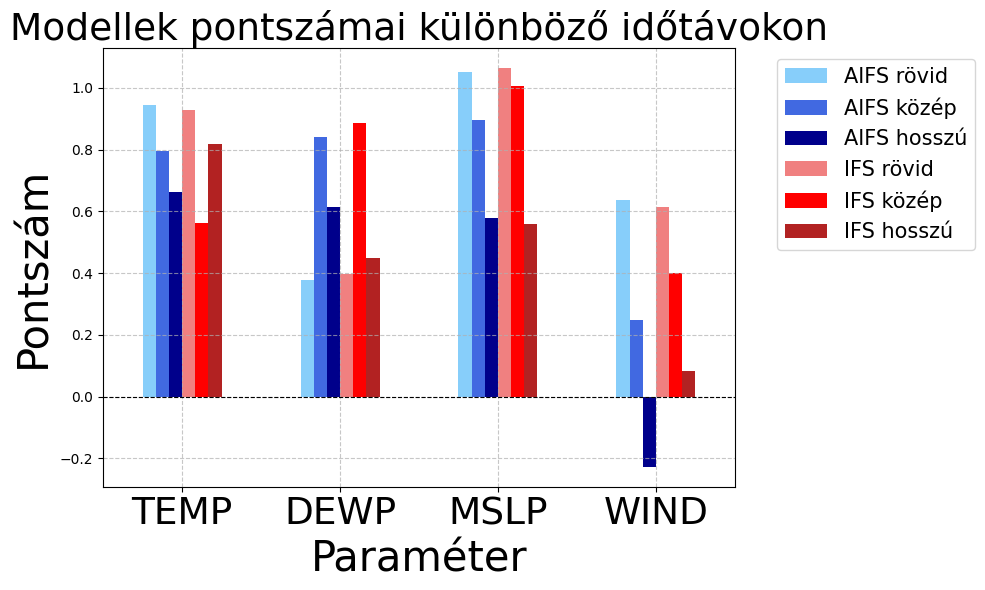

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Adatok létrehozása Pandas DataFrame-ként
data = {
    'AIFS rövid': [0.943, 0.3781, 1.0505, 0.6364],
    'AIFS közép': [0.7938, 0.8417, 0.8971, 0.2496],
    'AIFS hosszú': [0.662, 0.6134, 0.579, -0.2274],
    'IFS rövid': [0.9281, 0.3976, 1.0634, 0.615],
    'IFS közép': [0.5631, 0.886, 1.0057, 0.4008],
    'IFS hosszú': [0.818, 0.4489, 0.5576, 0.084]
}

index_labels = ['TEMP', 'DEWP', 'MSLP', 'WIND']
df = pd.DataFrame(data, index=index_labels)

# 2. Színlista definiálása angol színnevekkel
# 6 oszlophoz 6 színt kell megadni
custom_colors = [
    'lightskyblue',       # AIFS rövid
    'royalblue',      # AIFS közép
    'darkblue',     # AIFS hosszú
    'lightcoral',        # IFS rövid
    'red',     # IFS közép
    'firebrick'       # IFS hosszú
]

# 3. Barplot készítése a 'color' paraméterrel
ax = df.plot(
    kind='bar',
    figsize=(10,6),
    rot=0,
    color=custom_colors # Szöveges színnevek használata
)

# 4. Diagram testreszabása
plt.title('Modellek pontszámai különböző időtávokon', fontsize=27)
plt.ylabel('Pontszám', fontsize=30)
plt.xlabel('Paraméter', fontsize=30)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # 0-vonal feketére állítva
ax.legend(fontsize=15, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
#plt.grid(True)
ax.tick_params(axis='x', labelsize=27)
plt.tight_layout()
plt.show()

**Globális pontszám**

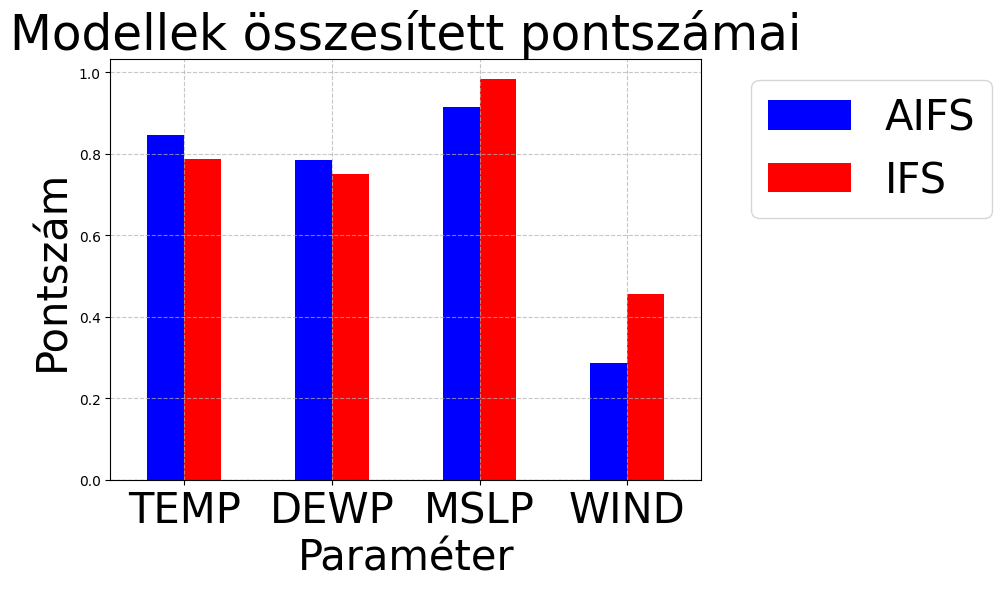

In [19]:
data = {
    'AIFS': [0.8465, 0.7835, 0.9150, 0.2872],
    'IFS': [0.7874, 0.7502, 0.9830, 0.4556]
}

index_labels = ['TEMP', 'DEWP', 'MSLP', 'WIND']
df = pd.DataFrame(data, index=index_labels)

custom_colors = [
    'blue',
    'red'
]

# 3. Barplot készítése a 'color' paraméterrel
ax = df.plot(
    kind='bar',
    figsize=(10,6),
    rot=0,
    color=custom_colors # Szöveges színnevek használata
)

# 4. Diagram testreszabása
plt.title('Modellek összesített pontszámai', fontsize=35)
plt.ylabel('Pontszám', fontsize=30)
plt.xlabel('Paraméter', fontsize=30)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # 0-vonal feketére állítva
ax.legend(fontsize=30, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=30)
plt.tight_layout()
plt.show()

**LOKÁLIS PONTSZÁM**

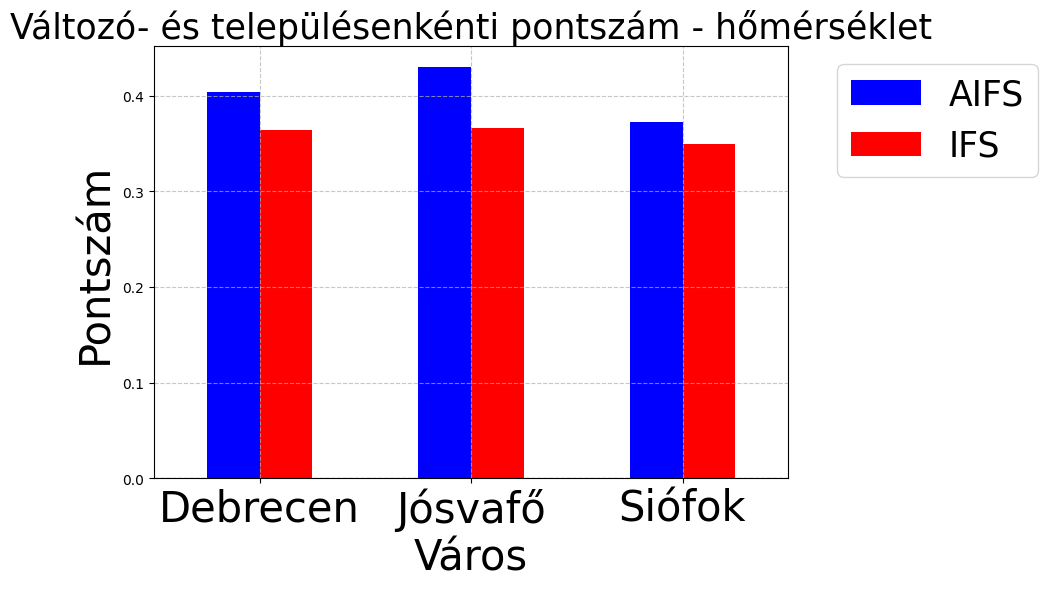

In [15]:
data_temp = {
    'AIFS': [0.4040, 0.4301, 0.3728],
    'IFS': [0.3641, 0.3658, 0.3494]
}

varos_labels = ['Debrecen', 'Jósvafő', 'Siófok']
df_temp = pd.DataFrame(data_temp, index=varos_labels)

custom_colors = [
    'blue',
    'red'
]

# 3. Barplot készítése a 'color' paraméterrel
ax = df_temp.plot(
    kind='bar',
    figsize=(10,6),
    rot=0,
    color=custom_colors # Szöveges színnevek használata
)

# 4. Diagram testreszabása
plt.title('Változó- és településenkénti pontszám - hőmérséklet', fontsize=25)
plt.ylabel('Pontszám', fontsize=30)
plt.xlabel('Város', fontsize=30)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # 0-vonal feketére állítva
ax.legend(fontsize=25, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=30)
plt.tight_layout()
plt.show()

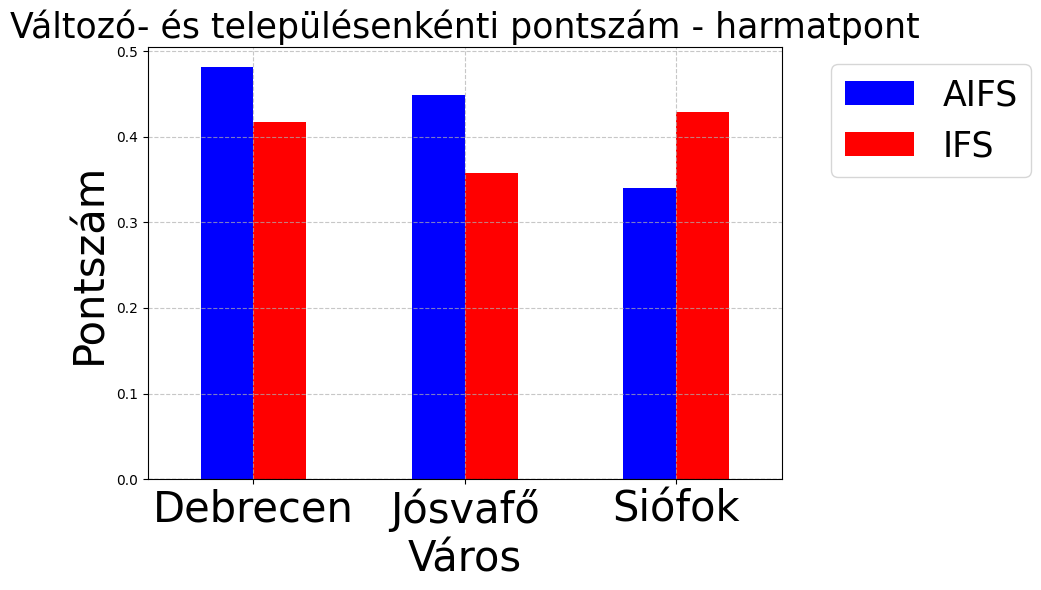

In [16]:
data_dewp = {
    'AIFS': [0.4809, 0.4488, 0.3399],
    'IFS': [0.4168, 0.3575, 0.4287]
}

varos_labels = ['Debrecen', 'Jósvafő', 'Siófok']
df_dewp = pd.DataFrame(data_dewp, index=varos_labels)

custom_colors = [
    'blue',
    'red'
]

# 3. Barplot készítése a 'color' paraméterrel
ax = df_dewp.plot(
    kind='bar',
    figsize=(10,6),
    rot=0,
    color=custom_colors # Szöveges színnevek használata
)

# 4. Diagram testreszabása
plt.title('Változó- és településenkénti pontszám - harmatpont', fontsize=25)
plt.ylabel('Pontszám', fontsize=30)
plt.xlabel('Város', fontsize=30)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # 0-vonal feketére állítva
ax.legend(fontsize=25, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=30)
plt.tight_layout()
plt.show()

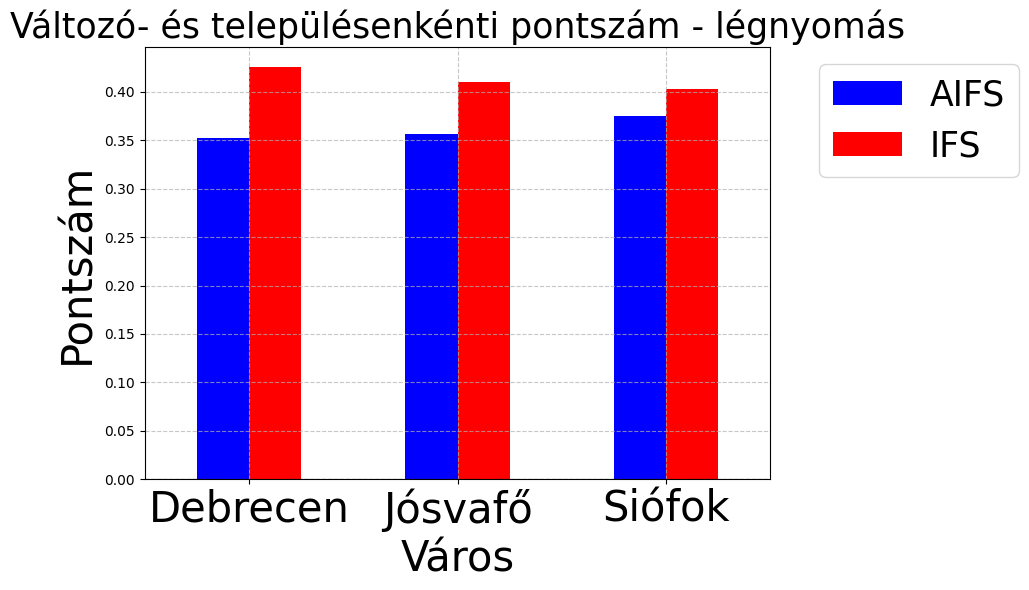

In [17]:
data_mslp = {
    'AIFS': [0.3529, 0.3562, 0.3752],
    'IFS': [0.4253, 0.4098, 0.4034]
}

varos_labels = ['Debrecen', 'Jósvafő', 'Siófok']
df_mslp = pd.DataFrame(data_mslp, index=varos_labels)

custom_colors = [
    'blue',
    'red'
]

# 3. Barplot készítése a 'color' paraméterrel
ax = df_mslp.plot(
    kind='bar',
    figsize=(10,6),
    rot=0,
    color=custom_colors # Szöveges színnevek használata
)

# 4. Diagram testreszabása
plt.title('Változó- és településenkénti pontszám - légnyomás', fontsize=25)
plt.ylabel('Pontszám', fontsize=30)
plt.xlabel('Város', fontsize=30)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # 0-vonal feketére állítva
ax.legend(fontsize=25, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=30)
plt.tight_layout()
plt.show()

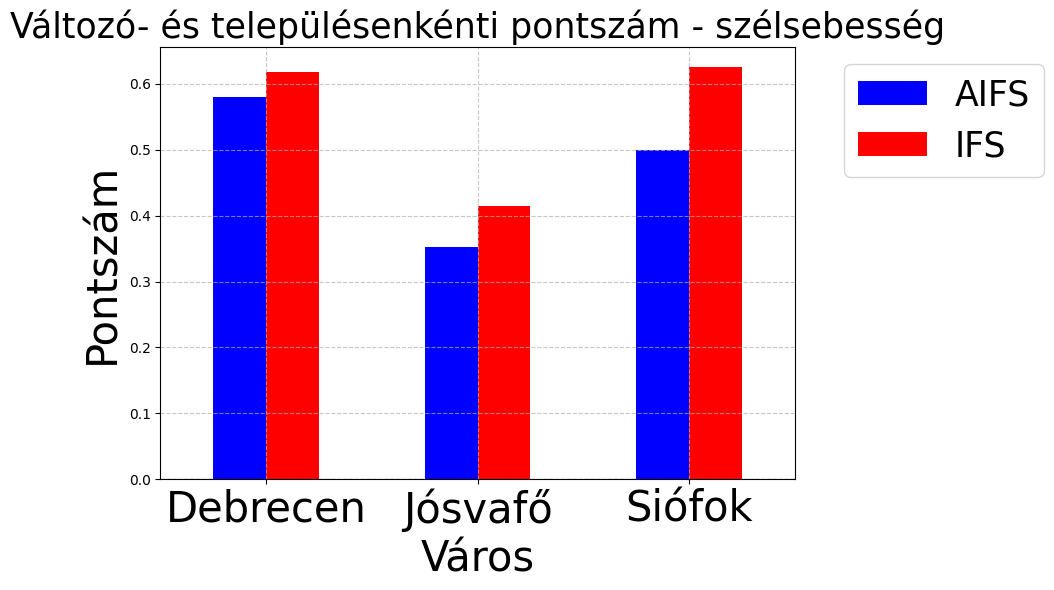

In [18]:
data_wind = {
    'AIFS': [0.5804, 0.3520, 0.4991],
    'IFS': [0.6186, 0.4142, 0.6250]
}

varos_labels = ['Debrecen', 'Jósvafő', 'Siófok']
df_wind = pd.DataFrame(data_wind, index=varos_labels)

custom_colors = [
    'blue',
    'red'
]

# 3. Barplot készítése a 'color' paraméterrel
ax = df_wind.plot(
    kind='bar',
    figsize=(10,6),
    rot=0,
    color=custom_colors # Szöveges színnevek használata
)

# 4. Diagram testreszabása
plt.title('Változó- és településenkénti pontszám - szélsebesség', fontsize=25)
plt.ylabel('Pontszám', fontsize=30)
plt.xlabel('Város', fontsize=30)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # 0-vonal feketére állítva
ax.legend(fontsize=25, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=30)
plt.tight_layout()
plt.show()

**BS**

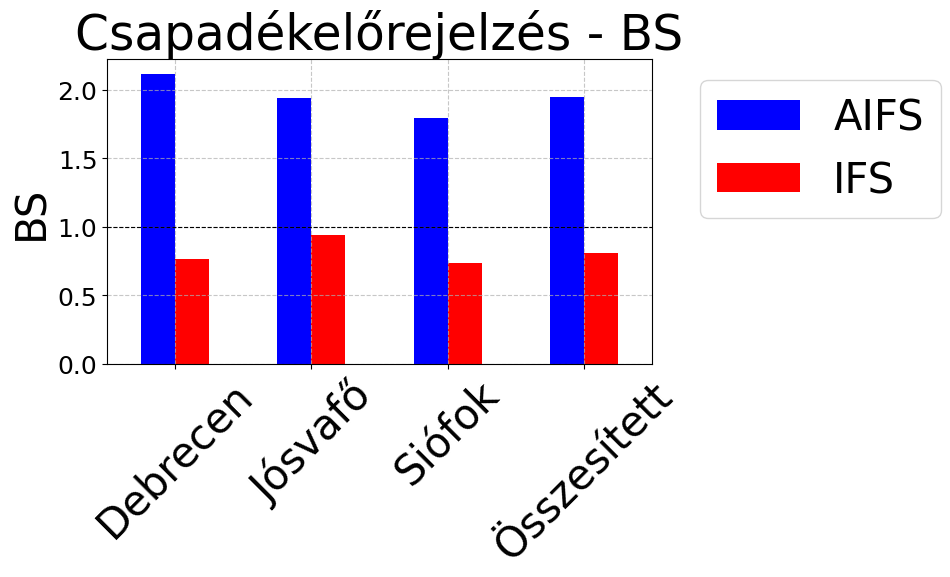

In [50]:
data_BS = {
    'AIFS': [2.1176, 1.9412, 1.7895, 1.9434],
    'IFS': [0.7647, 0.9412, 0.7368, 0.8113]
}

varos_labels = ['Debrecen', 'Jósvafő', 'Siófok', 'Összesített']
df_BS = pd.DataFrame(data_BS, index=varos_labels)

custom_colors = [
    'blue',
    'red'
]

# 3. Barplot készítése a 'color' paraméterrel
ax = df_BS.plot(
    kind='bar',
    figsize=(10,6),
    rot=45,
    color=custom_colors # Szöveges színnevek használata
)

# 4. Diagram testreszabása
plt.title('Csapadékelőrejelzés - BS', fontsize=35)
plt.ylabel('BS', fontsize=30)
#plt.xlabel('Város', fontsize=30)
plt.axhline(1, color='black', linestyle='--', linewidth=0.8) # 0-vonal feketére állítva
ax.legend(fontsize=30, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=30)
plt.tight_layout()
plt.show()

**POD**

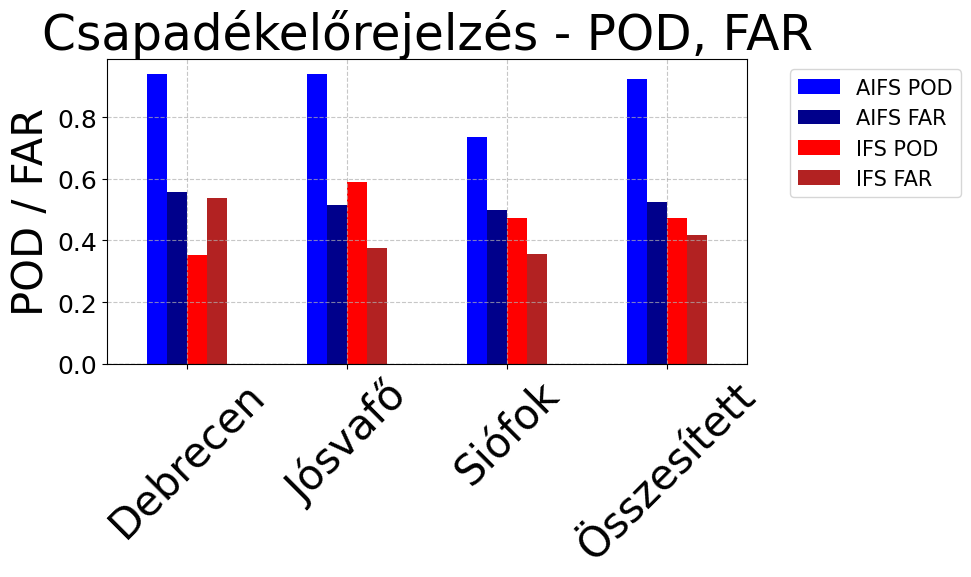

In [52]:
data_POD_FAR = {
    'AIFS POD': [0.9412, 0.9412, 0.7368, 0.9245],
    'AIFS FAR': [0.5556, 0.5152, 0.5, 0.5243],
    'IFS POD': [0.3529, 0.5882, 0.4737, 0.4717],
    'IFS FAR': [0.5385, 0.3750, 0.3571, 0.4186]
}

varos_labels = ['Debrecen', 'Jósvafő', 'Siófok', 'Összesített']
df_POD_FAR = pd.DataFrame(data_POD_FAR, index=varos_labels)

custom_colors = [
    'blue',
    'darkblue',
    'red',
    'firebrick'
]

# 3. Barplot készítése a 'color' paraméterrel
ax = df_POD_FAR.plot(
    kind='bar',
    figsize=(10,6),
    rot=45,
    color=custom_colors # Szöveges színnevek használata
)

# 4. Diagram testreszabása
plt.title('Csapadékelőrejelzés - POD, FAR', fontsize=35)
plt.ylabel('POD / FAR', fontsize=30)
#plt.xlabel('Város', fontsize=30)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # 0-vonal feketére állítva
ax.legend(fontsize=15, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=30)
plt.tight_layout()
plt.show()

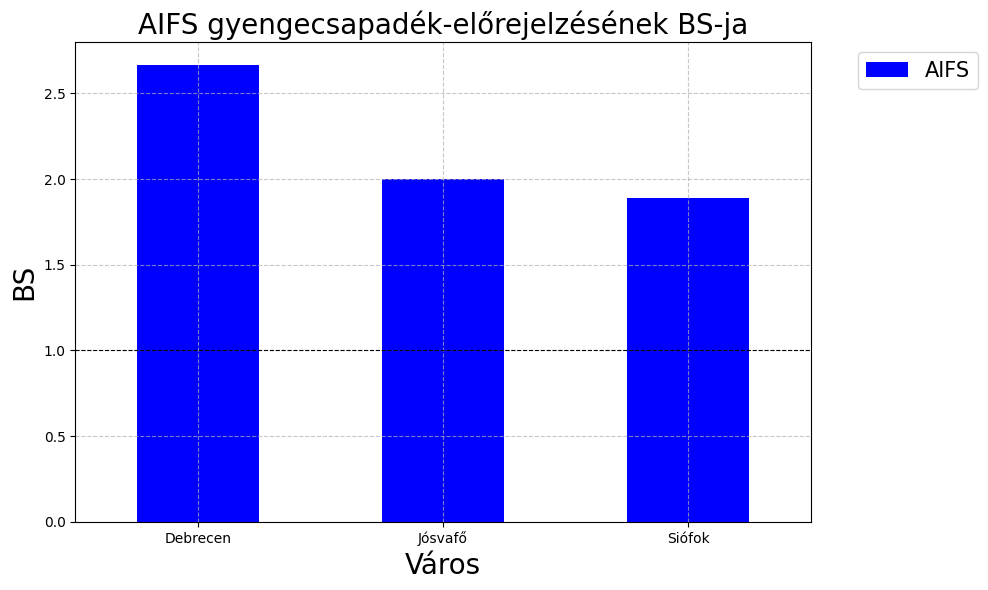

: 

In [ ]:
data_BS_AIFS = {
    'AIFS': [2.667, 2, 1.889]
}

varos_labels = ['Debrecen', 'Jósvafő', 'Siófok']
df_BS_AIFS = pd.DataFrame(data_BS_AIFS, index=varos_labels)

custom_colors = [
    'blue'
]

# 3. Barplot készítése a 'color' paraméterrel
ax = df_BS_AIFS.plot(
    kind='bar',
    figsize=(10,6),
    rot=0,
    color=custom_colors # Szöveges színnevek használata
)

# 4. Diagram testreszabása
plt.title('AIFS gyengecsapadék-előrejelzésének BS-ja', fontsize=20)
plt.ylabel('BS', fontsize=20)
plt.xlabel('Város', fontsize=20)
plt.axhline(1, color='black', linestyle='--', linewidth=0.8)
ax.legend(fontsize=15, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()